# Differential expression between WT and KD within celltypes

In [1]:
here::i_am("rna_atac/dimensionality_reduction/WNN_MOFA.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(Seurat))
suppressPackageStartupMessages(library(dplyr))

BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 21

# Multi core using future - built in to seurat
plan("multicore", workers = 16)
options(future.globals.maxSize = 50 * 1024 ^ 3) # for 50 Gb RAM

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code



In [2]:
args = list()
# RNA seurat 
args$rna_seurat = file.path(io$basedir, 'results/rna_atac/dimensionality_reduction/seurat_object.rds')
args$logFC_thr = 0.25
args$FDR_thr = 0.05

# outdir
args$outdir = file.path(io$basedir, 'results/rna_atac/differential/expression/')
dir.create(args$outdir, recursive=TRUE, showWarnings =FALSE)

#### Load Data

In [3]:
seurat = readRDS(args$rna_seurat)

In [4]:
seurat@meta.data$celltypes_v1 = opts$clusters2celltypes[match(as.character(seurat@meta.data$seurat_clusters), names(opts$clusters2celltypes))]

In [5]:
meta = as.data.table(seurat@meta.data, keep.rownames=T) %>% setnames('rn', 'cell')

In [6]:
# remove D3 cells
seurat = seurat[, meta[day!='D3']$cell]

In [7]:
Idents(seurat) = seurat@meta.data$genotype

#### Differential testing

In [8]:
find_DEGs = function(celltype_test, logFC_thr = args$logFC_thr, FDR_thr = args$FDR_thr, test = 'wilcox'){
    message(celltype_test)
    tmp = seurat[, meta[celltypes_v1==celltype_test]$cell]
    markers_tmp = FindMarkers(tmp, ident.1 = "eomes_ko", ident.2 = "wt",
      logfc.threshold = 0.1, test.use = test)
    tmp = as.data.table(markers_tmp, keep.rownames=T) %>%
        setnames('rn', 'gene') %>% 
        .[,sig:=ifelse(abs(avg_log2FC)>logFC_thr & p_val_adj <= FDR_thr, TRUE, FALSE)] %>% 
        .[,celltype:=celltype_test]
    return(tmp)
}  

volcano_plot = function(dt, ntop=5, logFC_thr = args$logFC_thr, FDR_thr = args$FDR_thr, title=NULL){
    tmp = dt[,sign:=ifelse(p_val_adj < FDR_thr & abs(avg_log2FC) > logFC_thr, ifelse(avg_log2FC>0, 'pos', 'neg'), 'nonsig')] %>%
        .[order(-abs(avg_log2FC))]
    labels = tmp[, head(.SD, ntop),  by=sign][sign!='nonsig']
    
    p = ggplot(tmp, aes(avg_log2FC, -log10(p_val_adj), col=sign)) + 
        geom_point() +  
        scale_colour_manual(values=c('pos' = 'red', 'neg' = 'blue', 'nonsig' = 'black')) + 
        geom_vline(xintercept=c(-logFC_thr, logFC_thr),  linetype = "longdash") +
        geom_vline(xintercept=0, color='orange', linetype = "longdash") +
        geom_hline(yintercept=-log10(FDR_thr),  linetype = "longdash") + 
        ggrepel::geom_text_repel(data=labels, aes(label=gene), 
                                 color='black',
                                 size=5,
                                 box.padding = 0.5, 
                                 max.overlaps = Inf,
                                 bg.color='white', 
                                 bg.r = 0.1) + 
        xlim(c(-max(abs(tmp$avg_log2FC)), max(abs(tmp$avg_log2FC)))) + 
        ggtitle(title) + 
        theme_bw() + 
        theme(text = element_text(size=15, color='black'),
             axis.text = element_text(size=15, color='black'),
             legend.position = 'none')

    
    return(p)
}

In [9]:
keep = unique(opts$clusters2celltypes)[unique(opts$clusters2celltypes) != 'blood']

In [10]:
keep

[1] "Primitive_Streak"                 "Mesoderm_Eomes+_PdgfRa+"         
 [3] "Mesoderm_Eomes-_T+"               "Mesoderm_Meis2+"                 
 [5] "Posterior_Mesoderm_Cdx4+_Hoxa9+"  "Mesenchyme_Podxl+_Foxf1+"        
 [7] "Allantois_Precursor_Tbx4+_Pitx1-" "Allantois"                       
 [9] "HE_precursor"                     "HE"                              
[11] "Endothelium"

In [11]:
DEGs = mclapply(keep, find_DEGs, mc.cores=16) %>% rbindlist()

In [12]:
fwrite(DEGs, sprintf('%s/DEGs_seurat.txt.gz', args$outdir))

In [13]:
# Remove haemoglobin genes because useually batch effect
DEGs = DEGs[!gene %in% c('Hba-x', 'Hba-a1', 'Hba-a2', 'Hbb-bh1') ]

In [14]:
plots = mclapply(keep, function(x){
    tmp = DEGs[celltype==x]
    p = volcano_plot(tmp, ntop=10, title=x)
    return(p)
})

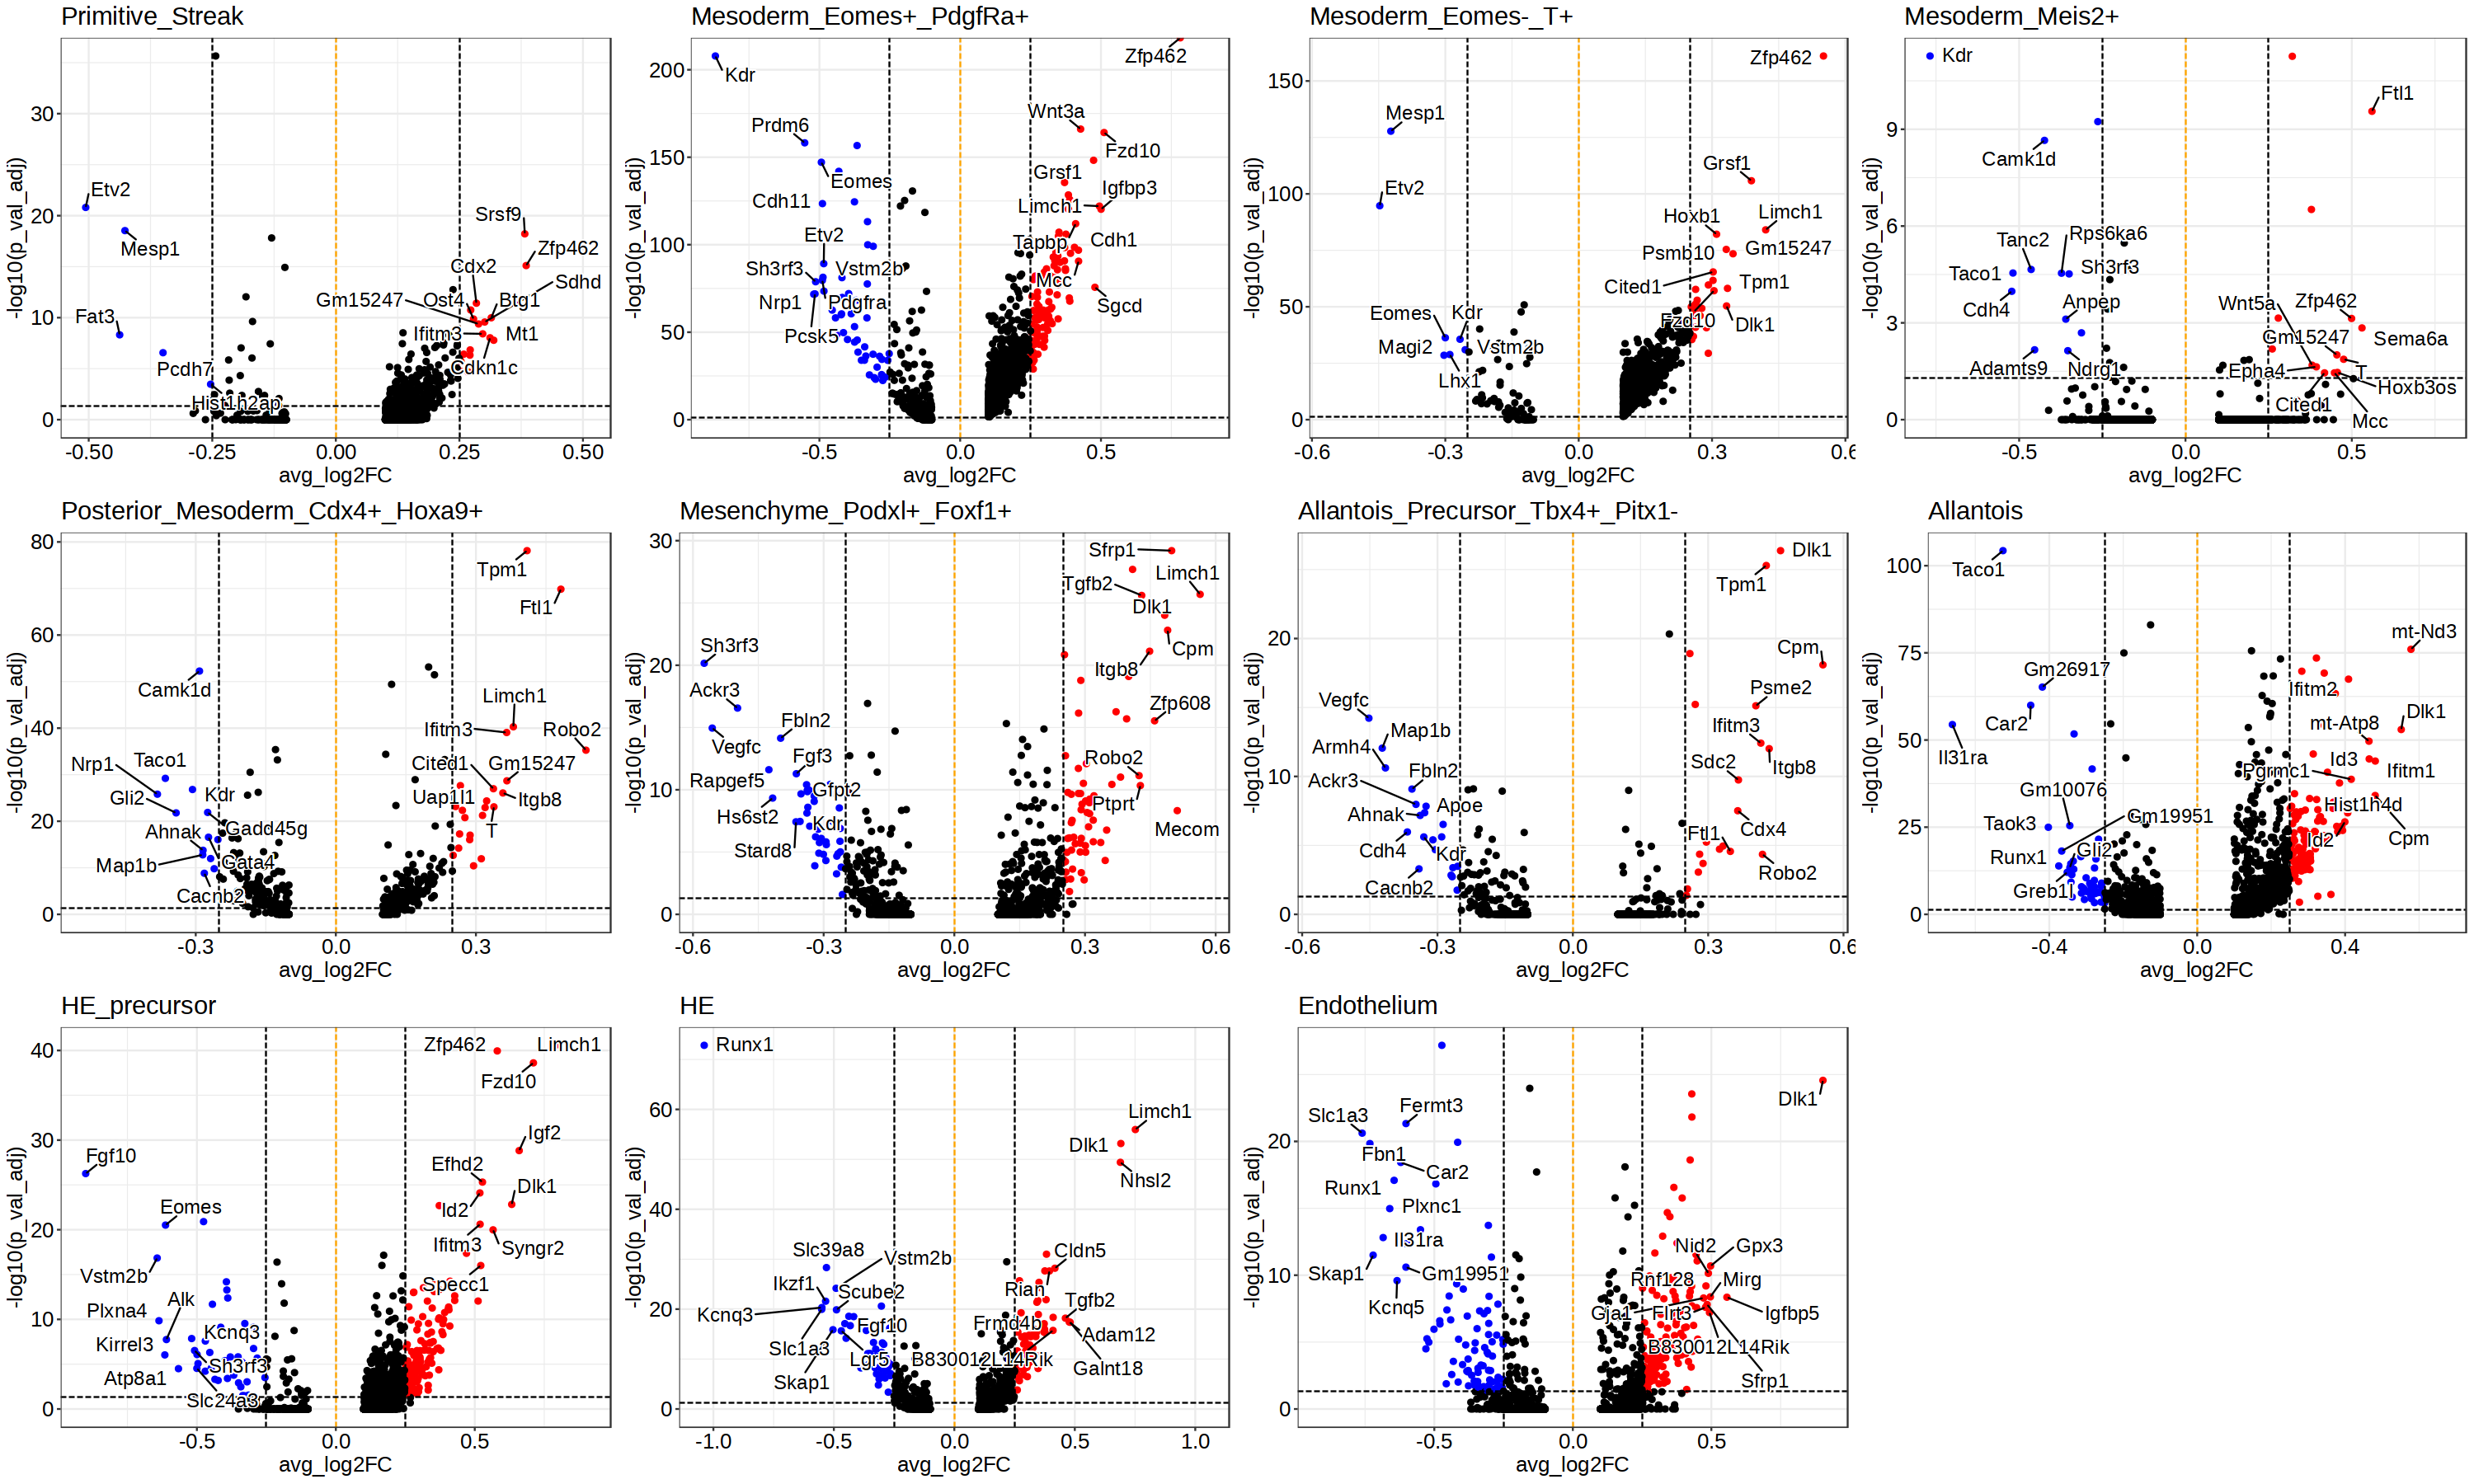

In [15]:
options(repr.plot.width=25, repr.plot.height=15)
ggarrange(plotlist=plots)

In [16]:
head(DEGs)

gene,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,sig,celltype
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<chr>
Fn1,6.869529e-41,-0.2430348,0.993,0.997,2.217828e-36,FALSE,Primitive_Streak
Etv2,4.831225e-26,-0.5060735,0.150,0.409,1.559761e-21,TRUE,Primitive_Streak
Mesp1,9.044585e-24,-0.4266519,0.499,0.661,2.920044e-19,TRUE,Primitive_Streak
Srsf9,1.874243e-23,0.3823515,0.765,0.437,6.050993e-19,TRUE,Primitive_Streak
mt-Atp6,4.738659e-23,-0.1299095,0.989,1.000,1.529876e-18,FALSE,Primitive_Streak
Zfp462,2.419749e-20,0.3851379,0.725,0.451,7.812158e-16,TRUE,Primitive_Streak


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


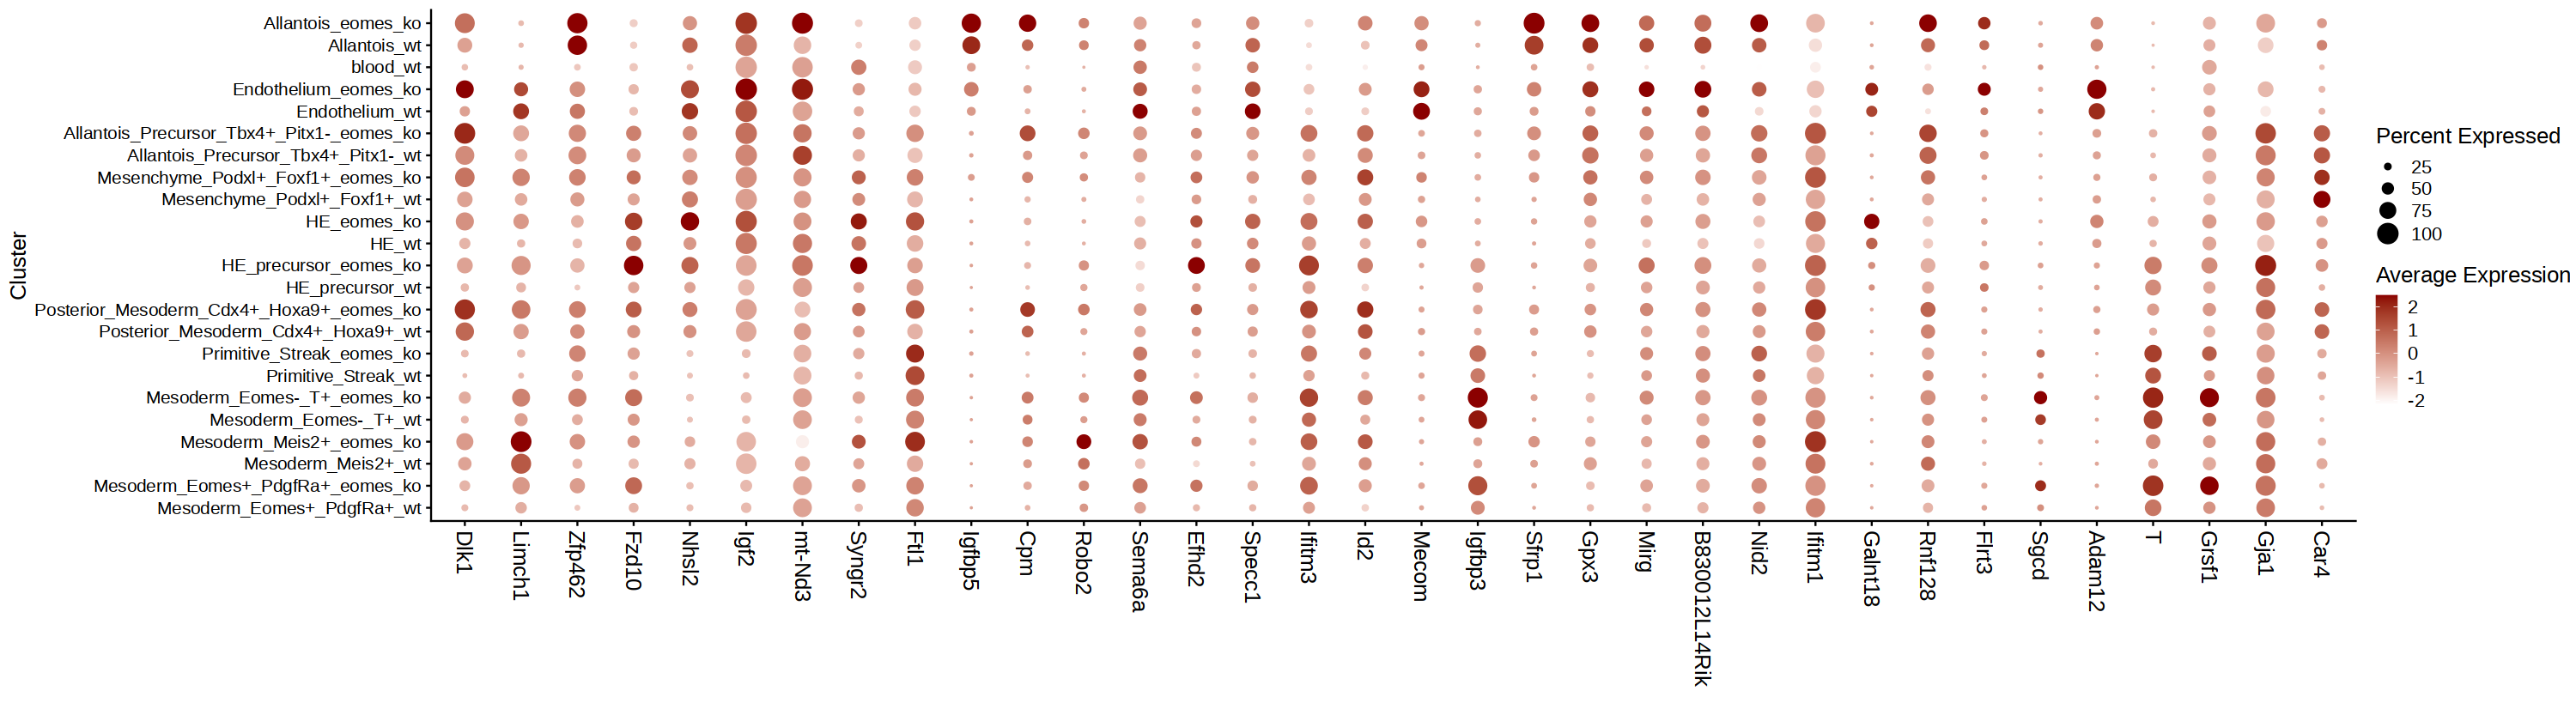

In [17]:
levels = lapply(unique(seurat@meta.data$celltypes_v1), function(x){
        t = paste0(x, c('_wt', '_eomes_ko'))
}) %>% unlist

seurat@meta.data$celltypes_genotype = factor(paste0(seurat@meta.data$celltypes_v1, '_', seurat@meta.data$genotype), levels = levels)
DEGs = DEGs[!gene %in% c('Hba-x', 'Hba-a1', 'Hba-a2', 'Hbb-bh1') ]

features = unique(DEGs[p_val_adj<0.05] %>% .[order(-avg_log2FC), gene] %>% head(50))

options(repr.plot.width=25, repr.plot.height=7)
DotPlot(seurat, features = unique(features), group.by = 'celltypes_genotype') + 
    scale_color_gradient(low='white', high='darkred', name='Average Expression') + 
    RotatedAxis() +
    ylab('Cluster') + xlab('') +
    theme(text=element_text(size=15), 
                         axis.text.x=element_text(angle=-90,hjust=0,vjust=0.5, size=15), 
                         axis.text.y=element_text(hjust=1))

# EdgeR

In [13]:
volcano_plot = function(dt, ntop=5, logFC_thr = args$logFC_thr, FDR_thr = args$FDR_thr, title=NULL){
    tmp = dt[,sign:=ifelse(padj_fdr < FDR_thr & abs(logFC) > logFC_thr, ifelse(logFC>0, 'pos', 'neg'), 'nonsig')] %>%
        .[order(-abs(logFC))]
    labels = tmp[, head(.SD, ntop),  by=sign][sign!='nonsig']
    
    p = ggplot(tmp, aes(logFC, -log10(padj_fdr), col=sign)) + 
        geom_point() + 
        scale_colour_manual(values=c('pos' = 'red', 'neg' = 'blue', 'nonsig' = 'black')) + 
        geom_vline(xintercept=c(-logFC_thr, logFC_thr),  linetype = "longdash") +
        geom_vline(xintercept=0, color='orange', linetype = "longdash") +
        geom_hline(yintercept=-log10(FDR_thr),  linetype = "longdash") + 
        ggrepel::geom_text_repel(data=labels, aes(label=gene), 
                                 color='black',
                                 size=5,
                                 box.padding = 0.5, 
                                 max.overlaps = Inf,
                                 bg.color='white', 
                                 bg.r = 0.1) + 
        xlim(c(-max(abs(tmp$logFC)), max(abs(tmp$logFC)))) + 
        ggtitle(title) + 
        theme_bw() + 
        theme(text = element_text(size=15, color='black'),
             axis.text = element_text(size=15, color='black'),
             legend.position = 'none')

    
    return(p)
}

In [19]:
suppressPackageStartupMessages(library(edgeR))

In [36]:
cell_metadata.dt = meta[day != 'D3']
cell_metadata.dt = cell_metadata.dt[,group:=paste0(celltypes_v1, '.', genotype)]

args$min_cells = 25
args$fraction_cells_per_replicate = 0.4
args$nrep = 5
args$min_CDR = 0.35

# Define groups
opts$groups <- c(args$groupA,args$groupB)

In [21]:
##################################
## Create pseudobulk replicates ##
##################################

cell2replicate.dt <- lapply(unique(cell_metadata.dt$group), function(i){
  tmp <- cell_metadata.dt[group==i]
  if ((args$fraction_cells_per_replicate*nrow(tmp))<=args$min_cells) {
    ncells_per_replicate <- args$min_cells
  } else {
    ncells_per_replicate <- round(args$fraction_cells_per_replicate*nrow(tmp))
  }
  seq(1,args$nrep) %>% map(function(j) {
    tmp[sample.int(nrow(tmp),ncells_per_replicate)] %>% 
      .[,replicate:=sprintf("%s_rep%s",i,j)] %>%
      .[,c("cell","group","replicate")] %>% 
      return
  }) %>% rbindlist %>% return
}) %>% rbindlist

stats.dt <- cell2replicate.dt[,.(ncells=.N),c("group","replicate")]
print(stats.dt)

                          group                       replicate ncells
  1: Mesoderm_Eomes+_PdgfRa+.wt Mesoderm_Eomes+_PdgfRa+.wt_rep1   2480
  2: Mesoderm_Eomes+_PdgfRa+.wt Mesoderm_Eomes+_PdgfRa+.wt_rep2   2480
  3: Mesoderm_Eomes+_PdgfRa+.wt Mesoderm_Eomes+_PdgfRa+.wt_rep3   2480
  4: Mesoderm_Eomes+_PdgfRa+.wt Mesoderm_Eomes+_PdgfRa+.wt_rep4   2480
  5: Mesoderm_Eomes+_PdgfRa+.wt Mesoderm_Eomes+_PdgfRa+.wt_rep5   2480
 ---                                                                  
111:               Allantois.wt               Allantois.wt_rep1    200
112:               Allantois.wt               Allantois.wt_rep2    200
113:               Allantois.wt               Allantois.wt_rep3    200
114:               Allantois.wt               Allantois.wt_rep4    200
115:               Allantois.wt               Allantois.wt_rep5    200


In [22]:
sce = as.SingleCellExperiment(seurat)[,cell2replicate.dt$cell]
sce$group_by <- cell2replicate.dt$replicate

In [23]:
################
## Pseudobulk ##
################

sce_pseudobulk <- pseudobulk_sce_fn(
  x = sce,
  assay = "counts",
  by = "group_by",
  fun = "sum",
  scale = FALSE
)

assayNames(sce_pseudobulk) <- "counts"

In [24]:
###################
## Normalisation ##
###################

# log cpm
logcounts(sce_pseudobulk) <- log2(1e6*(sweep(counts(sce_pseudobulk),2,colSums(counts(sce_pseudobulk)),"/"))+1)

In [25]:
args$groupA = 'wt'
args$groupB = 'eomes_ko'
args$celltypes = unique(opts$clusters2celltypes)[unique(opts$clusters2celltypes) != 'blood']

In [26]:
sce_full = sce_pseudobulk
rm(sce_pseudobulk)

In [50]:
sce_full$celltype_v1 <- colnames(sce_full) %>% strsplit("\\.") %>% map_chr(1)
sce_full$genotype <- colnames(sce_full) %>% strsplit("\\.") %>% map_chr(2) %>% strsplit('_rep') %>% map_chr(1)
sce_full$celltype_genotype = paste0(sce_full$celltype, '_', sce_full$genotype)

In [28]:
head(sce_full$genotype)

[1] "eomes_ko" "eomes_ko" "eomes_ko" "eomes_ko" "eomes_ko" "wt"

In [22]:
keep = unique(opts$clusters2celltypes)[unique(opts$clusters2celltypes) != 'blood']

In [52]:
singlecell_sce = as.SingleCellExperiment(seurat)

In [66]:
summary(colnames(singlecell_sce) == cell_metadata.dt$cell)

   Mode    TRUE 
logical   28481 

In [73]:
DEGs = mclapply(keep, function(ct){
    tmp <- sprintf("%s_%s",ct,opts$groups)
    if (any(!tmp%in%unique(sce_full$celltype_genotype))) {
      warning("...")
      out <- data.table(gene=NA, logFC=NA, padj_fdr=NA, cdr_A=NA, cdr_B=NA)
      #fwrite(out, args$outfile, sep="\t", na="NA", quote=F)
    } else {
      message(ct)
      sce <- sce_full[,sce_full$celltype %in% ct]
      singlecell_sce <- singlecell_sce[,singlecell_sce$celltypes_v1 %in% ct]

        # subset genotypes
        stopifnot(opts$groups%in%sce$genotype)
        sce$genotype <- factor(sce$genotype, levels=opts$groups)

        #######################################
        ## Calculate Cellular Detection Rate ##
        #######################################

        cdr <- data.table(
          gene = rownames(singlecell_sce),
          cdr_A = rowMeans(logcounts(singlecell_sce[,singlecell_sce$genotype==args$groupA])>0) %>% round(2),
          cdr_B = rowMeans(logcounts(singlecell_sce[,singlecell_sce$genotype==args$groupB])>0) %>% round(2)
        )

        #######################
        ## Feature selection ##
        #######################
        # filter by CDR
        genes.to.use <- cdr[cdr_A>=args$min_CDR | cdr_B>=args$min_CDR,gene]

        ################################################
        ## Differential expression testing with edgeR ##
        ################################################

        # Convert SCE to DGEList
        sce_edger <- scran::convertTo(sce[genes.to.use,], type="edgeR")

        # Define design matrix (with intercept)
        design <- model.matrix(~sce$genotype)

        # Estimate dispersions
        sce_edger  <- estimateDisp(sce_edger,design)

        # Fit GLM
        fit <- glmQLFit(sce_edger,design)

        # Likelihood ratio test
        lrt <- glmQLFTest(fit)

        # Construct output data.frame
        out <- topTags(lrt, n=nrow(lrt))$table %>% as.data.table(keep.rownames=T) %>%
          setnames(c("gene","logFC","logCPM","LR","p.value","padj_fdr")) %>%
          .[,c("logCPM","LR","p.value"):=NULL] %>%
          .[,c("padj_fdr","logFC"):=list(signif(padj_fdr,digits=3), round(logFC,3))] %>%
          merge(cdr, by="gene", all.y=TRUE) %>%
          setorder(padj_fdr, na.last=T)
    }
    out = out %>% .[,celltype:=ct]
    return(out)
}, mc.cores=1) %>% rbindlist(., fill=TRUE)

Primitive_Streak

Mesoderm_Eomes+_PdgfRa+

Mesoderm_Eomes-_T+

Mesoderm_Meis2+

Posterior_Mesoderm_Cdx4+_Hoxa9+

Mesenchyme_Podxl+_Foxf1+

Allantois_Precursor_Tbx4+_Pitx1-

Allantois

HE_precursor

HE

Endothelium



In [76]:
fwrite(DEGs, sprintf('%s/DEGs_edgeR_pb.txt.gz', args$outdir))

In [3]:
DEGs = fread(sprintf('%s/DEGs_edgeR_pb.txt.gz', args$outdir))

In [4]:
DEGs = DEGs[!gene %in% c('Hba-x', 'Hba-a1', 'Hba-a2', 'Hbb-bh1') ]

In [8]:
DEGs[grep('Lhx', gene)][!is.na(logFC)]

gene,logFC,padj_fdr,cdr_A,cdr_B,celltype
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Lhx1,-1.059,1.34e-22,0.61,0.50,Mesoderm_Eomes+_PdgfRa+
Lhx1,-0.811,8.49e-22,0.55,0.47,Mesoderm_Eomes-_T+
Lhx1,-1.654,1.43e-14,0.35,0.20,HE_precursor


In [21]:
head(keep)

                                    
1 function (.x, .p, ...)            
2 {                                 
3     where <- where_if(.x, .p, ...)
4     .x[!is.na(where) & where]     
5 }                                 

In [24]:
plots = mclapply(keep, function(x){
    tmp = DEGs[celltype==x][!is.na(logFC)]
    p = volcano_plot(tmp, ntop=25, title=x, logFC_thr=0.75)
    return(p)
})

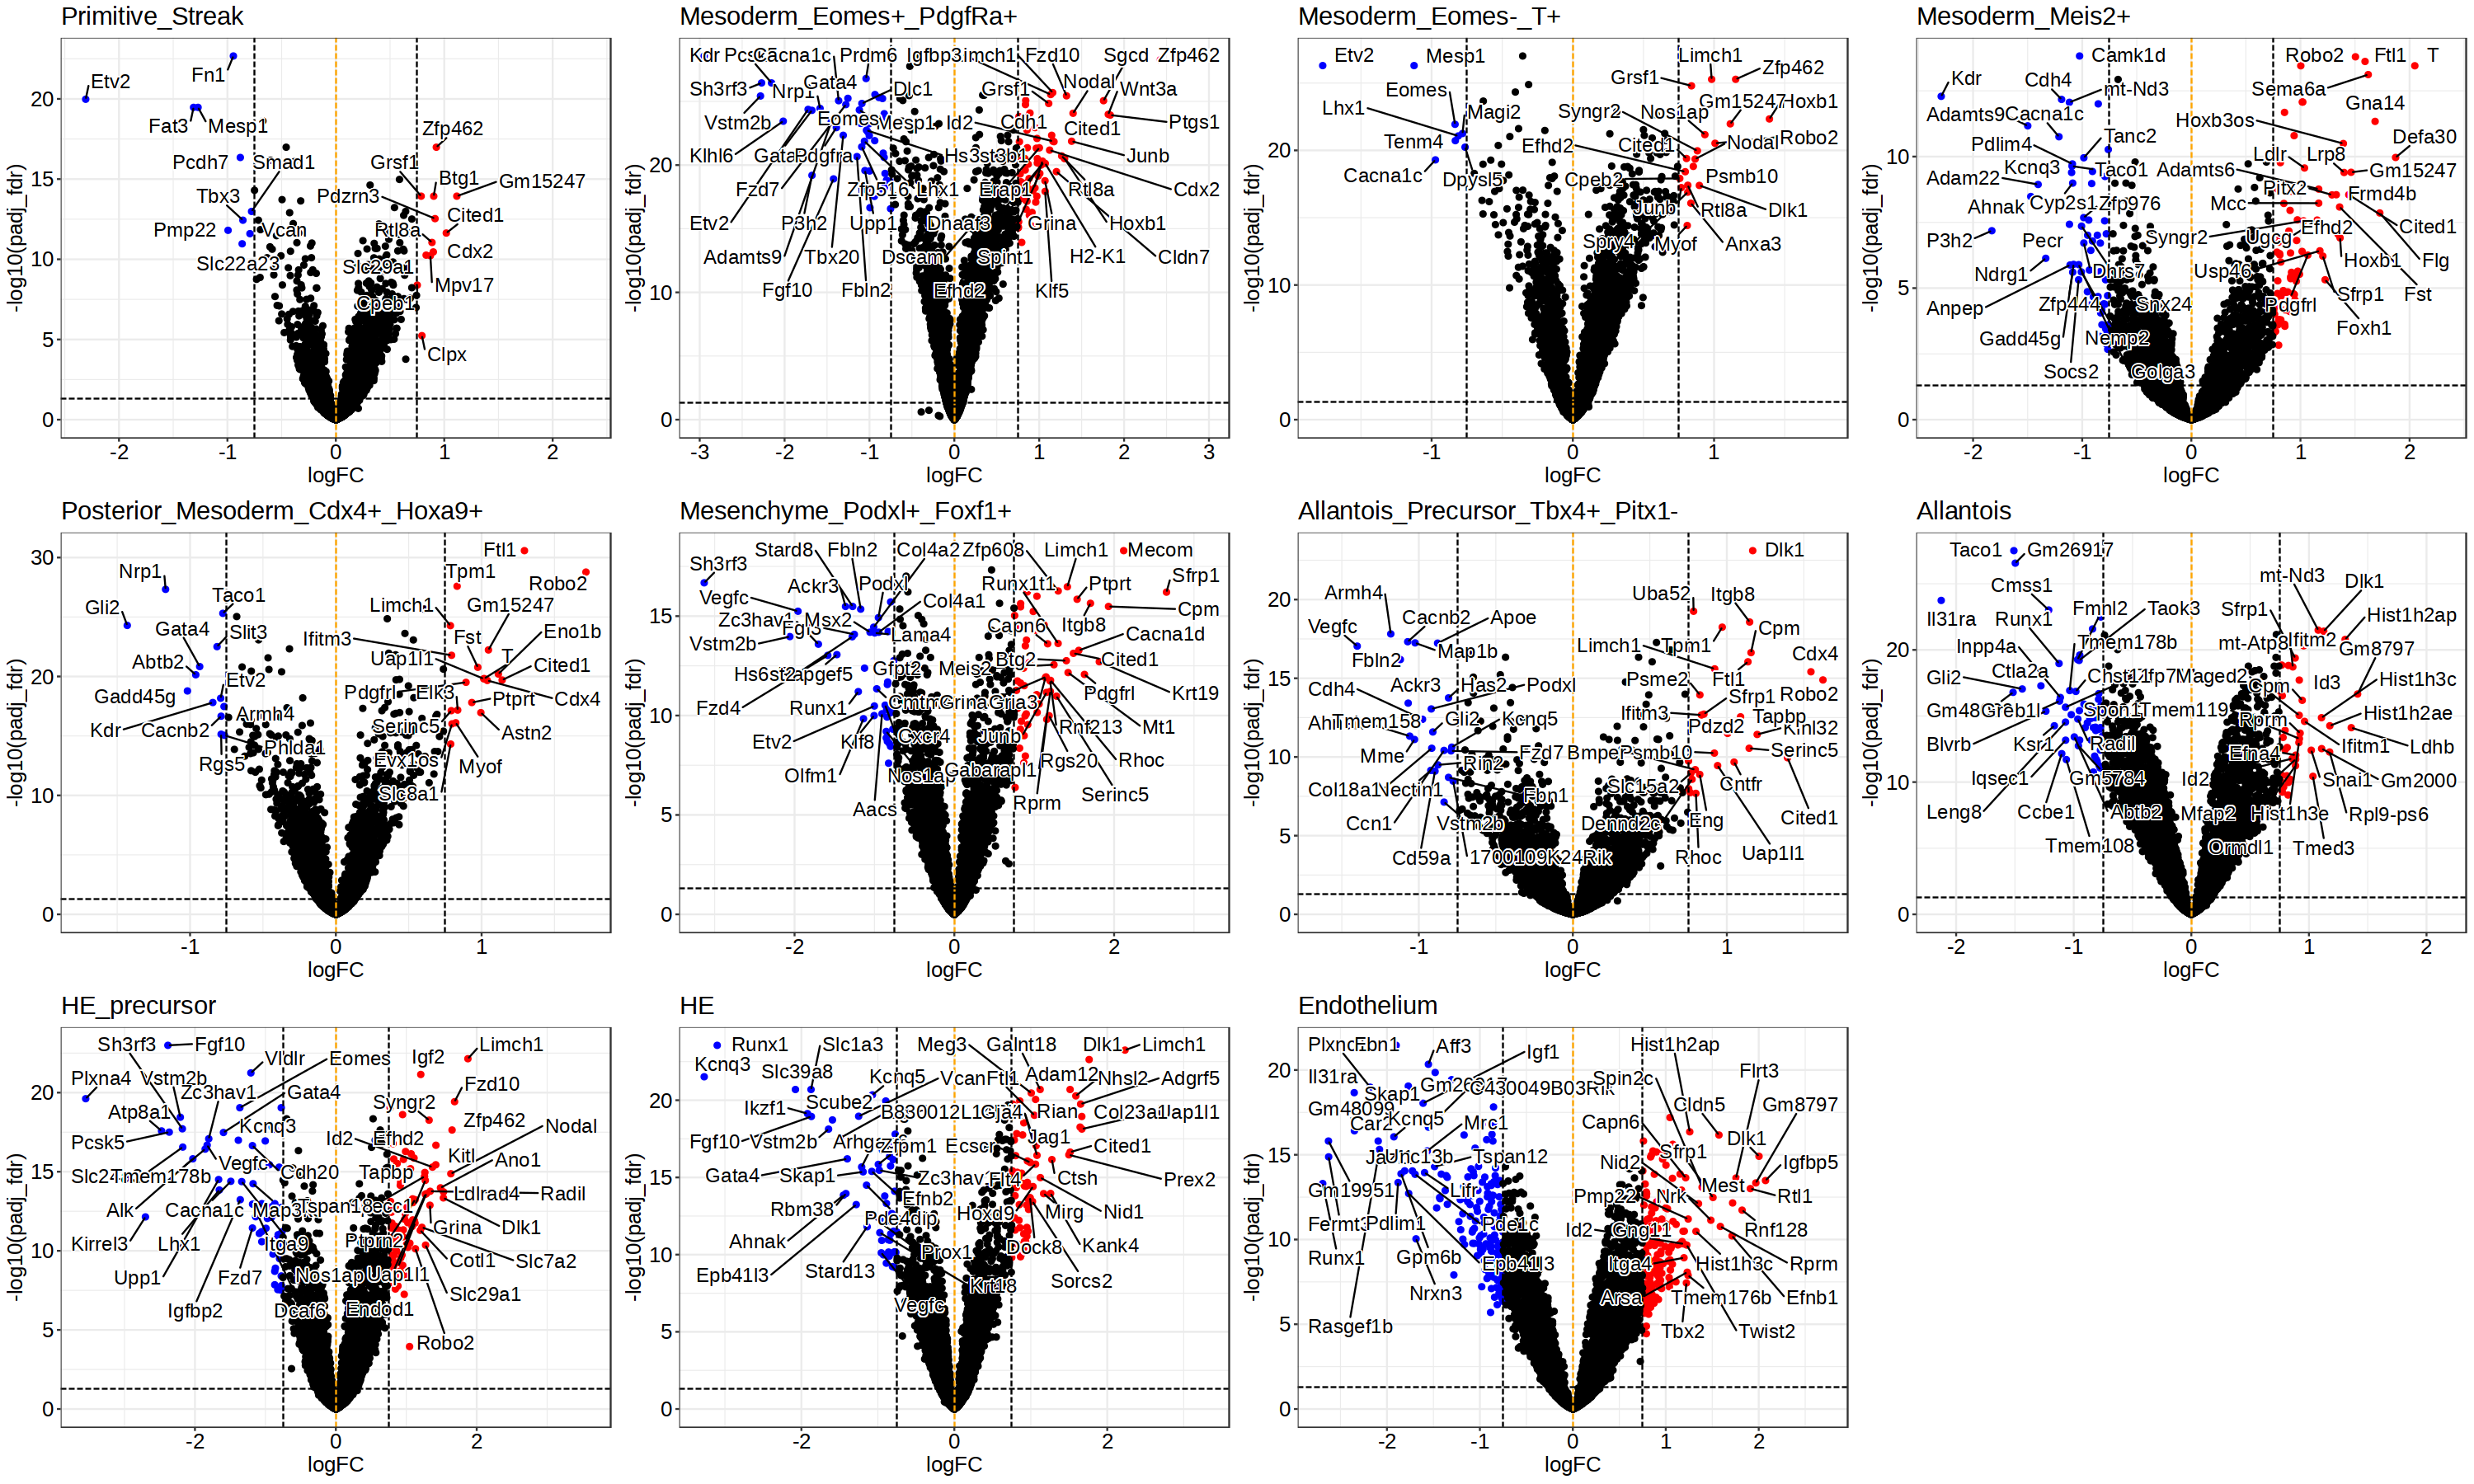

In [25]:
options(repr.plot.width=25, repr.plot.height=15)
ggarrange(plotlist=plots)

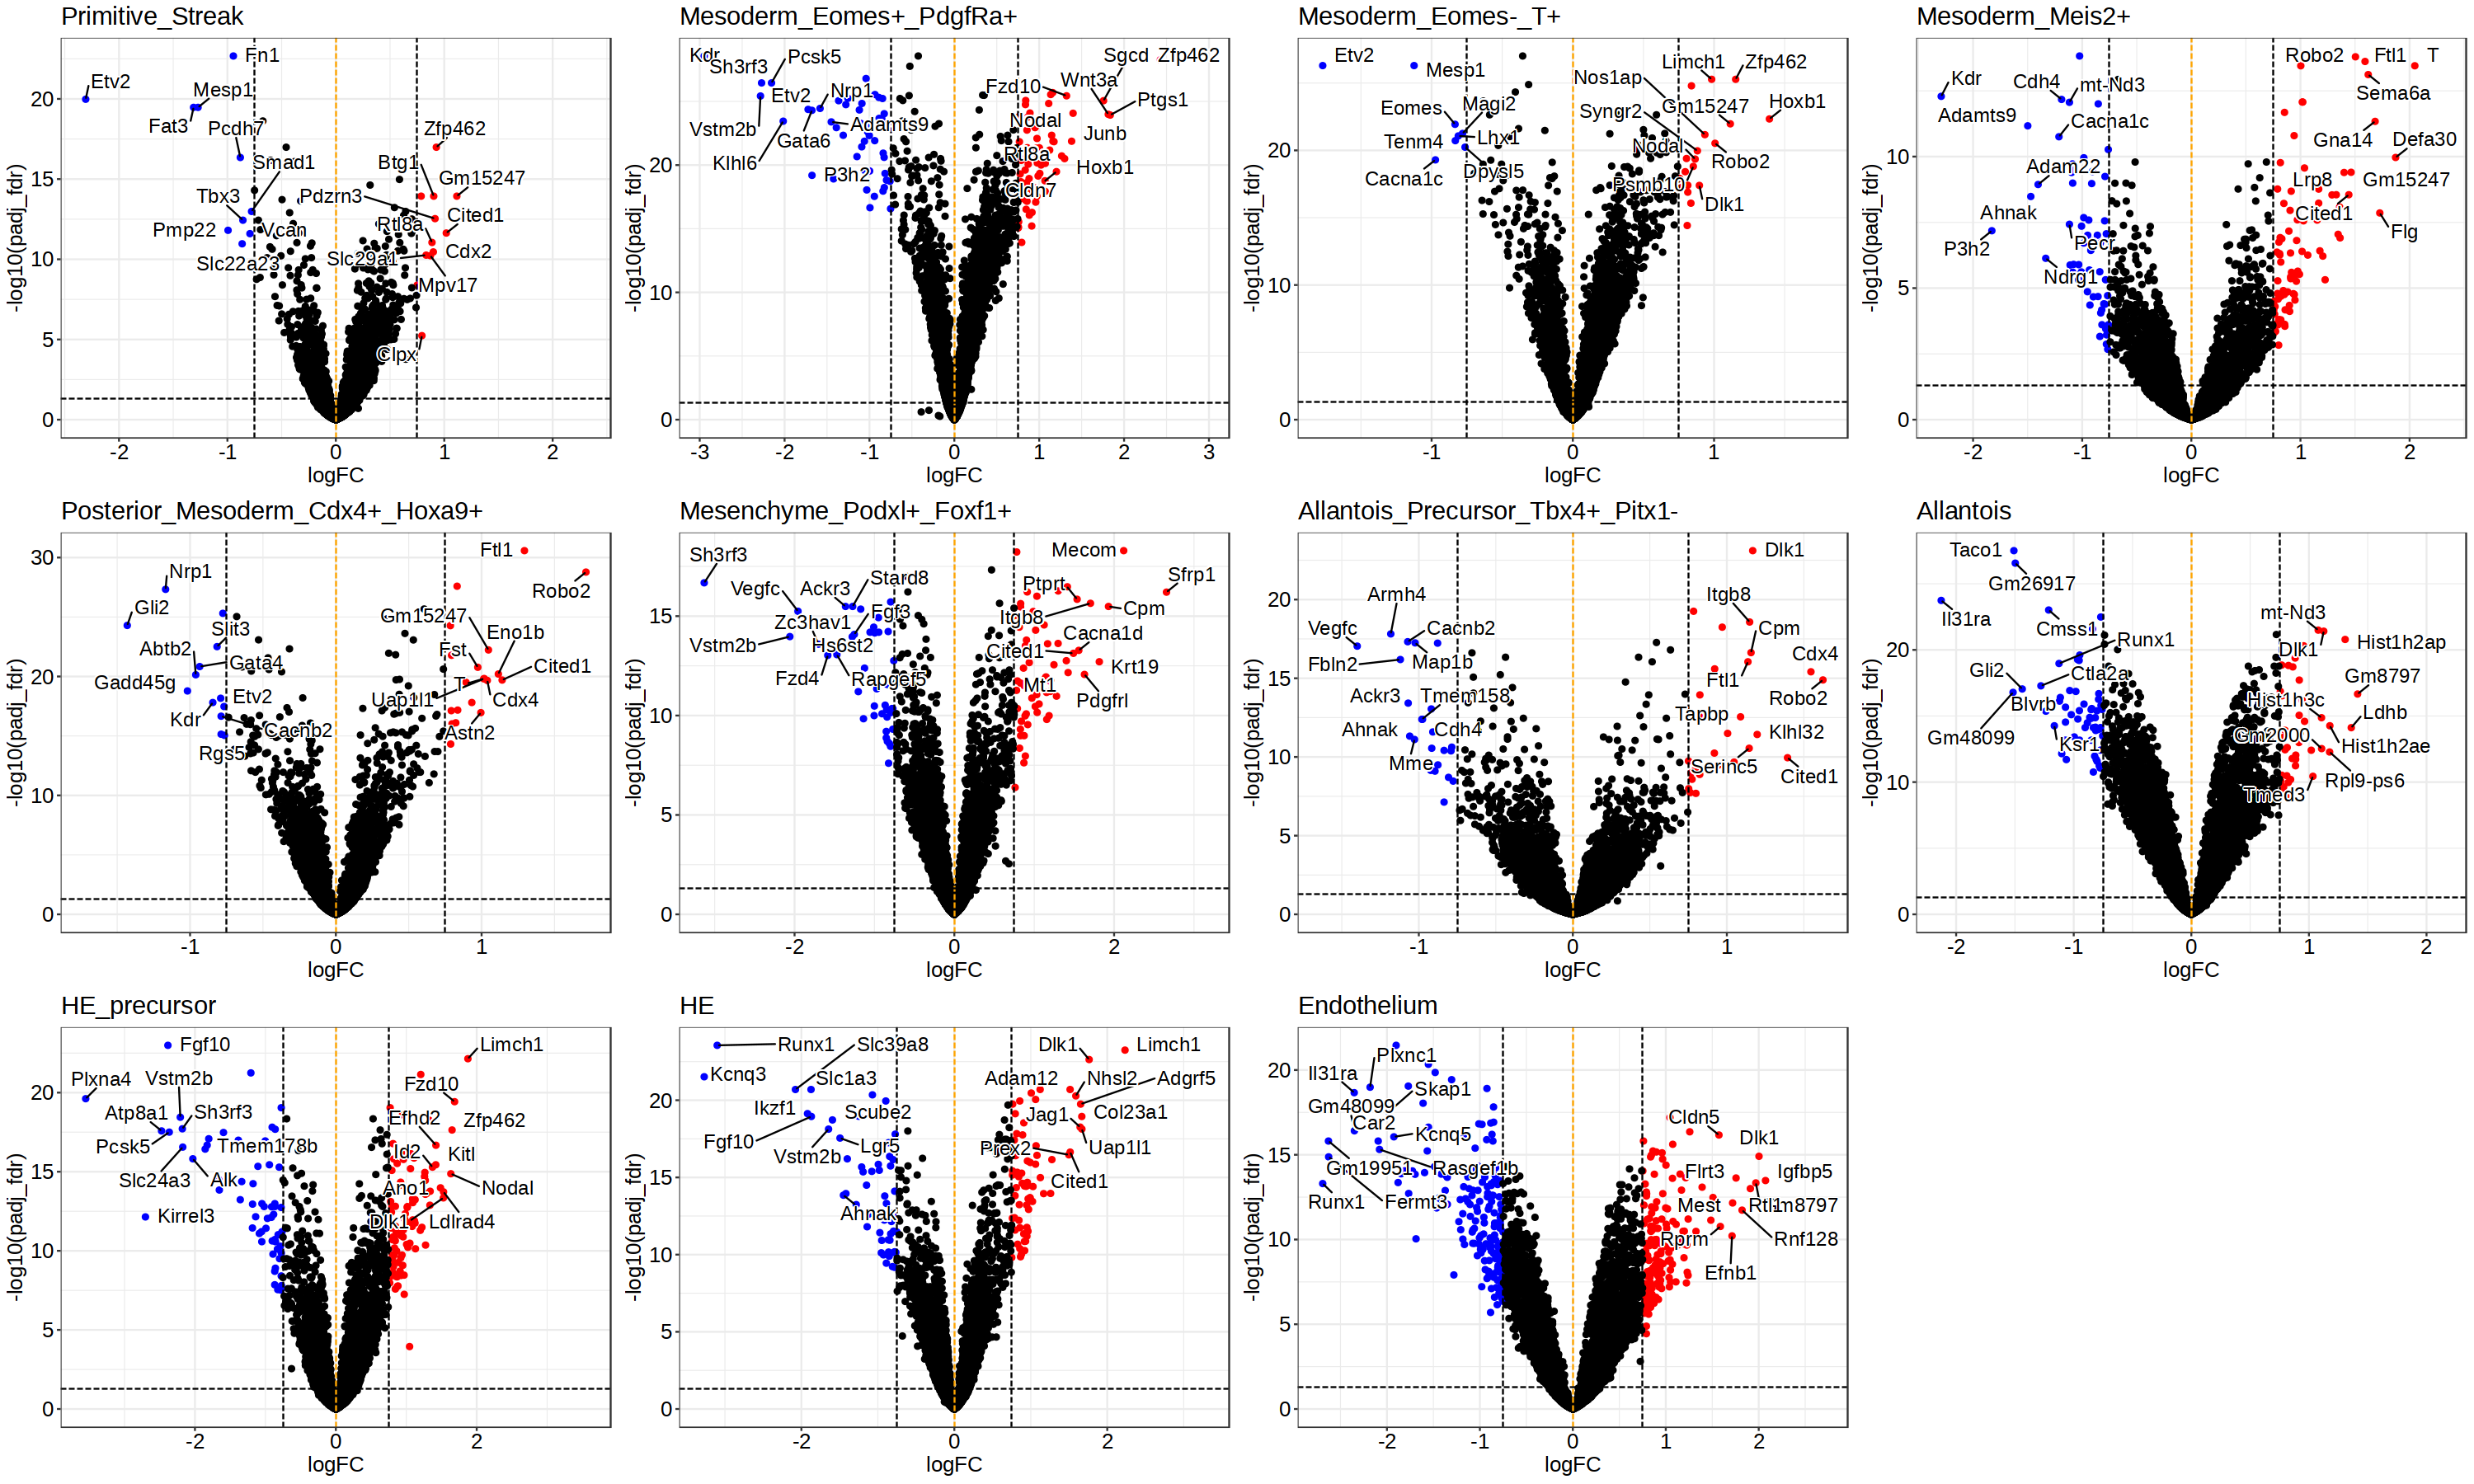

In [122]:
options(repr.plot.width=25, repr.plot.height=15)
ggarrange(plotlist=plots)

In [26]:
levels = lapply(unique(seurat@meta.data$celltypes_v1), function(x){
        t = paste0(x, c('_wt', '_eomes_ko'))
}) %>% unlist

ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'X' in selecting a method for function 'lapply': error in evaluating the argument 'x' in selecting a method for function 'unique': object 'seurat' not found


In [124]:
seurat@meta.data$celltypes_genotype = factor(paste0(seurat@meta.data$celltypes_v1, '_', seurat@meta.data$genotype), levels = levels)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


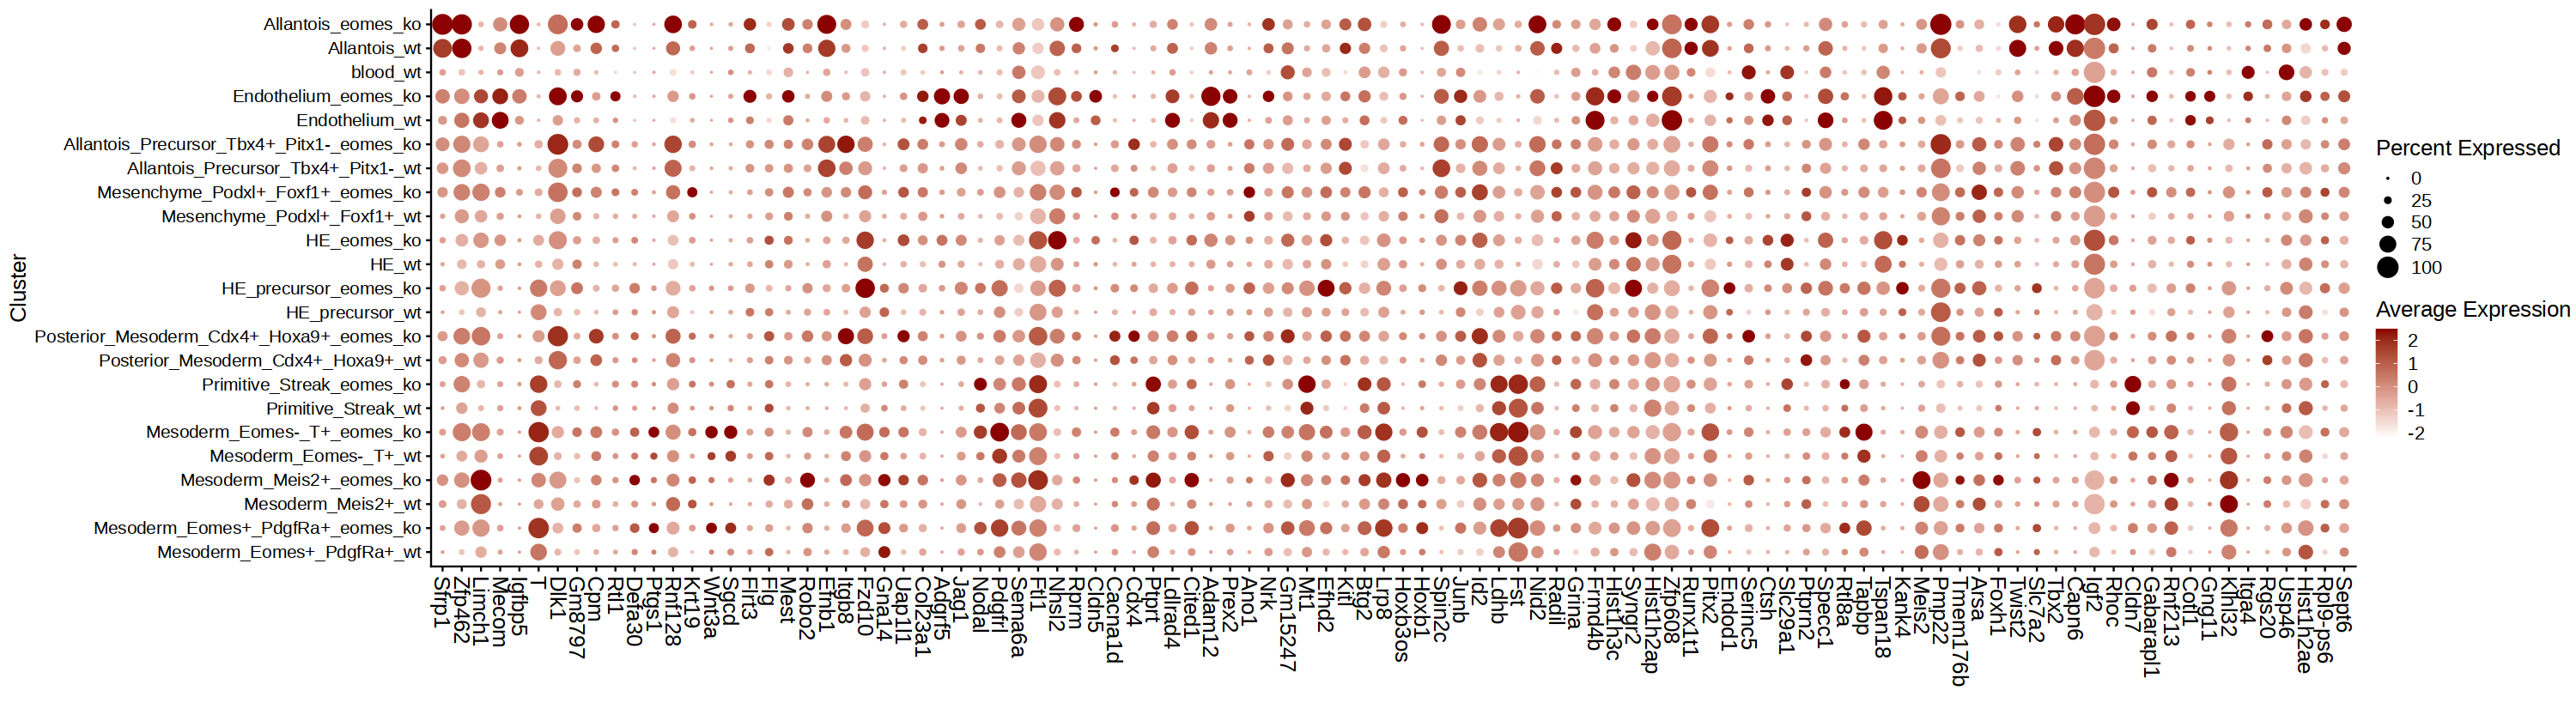

In [125]:
features = unique(DEGs[padj_fdr<0.05] %>% .[order(-logFC), gene]) %>% head(100)

options(repr.plot.width=25, repr.plot.height=7)
DotPlot(seurat, features = unique(features), group.by = 'celltypes_genotype') + 
    scale_color_gradient(low='white', high='darkred', name='Average Expression') + 
    RotatedAxis() +
    ylab('Cluster') + xlab('') +
    theme(text=element_text(size=15), 
                         axis.text.x=element_text(angle=-90,hjust=0,vjust=0.5, size=15), 
                         axis.text.y=element_text(hjust=1))

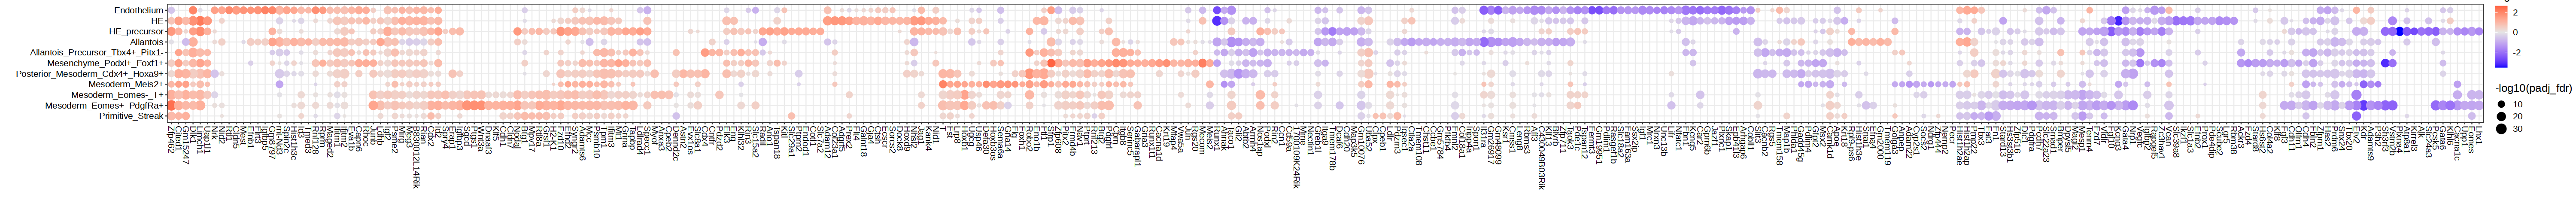

In [29]:
features = unique(DEGs[padj_fdr<0.05 & abs(logFC) > 0.75] %>% .[order(-abs(logFC)), ]) %>% .[,head(.SD, 50), by=celltype] %>% .$gene

# Turn dt in matrix
DEGs.mtx = DEGs[gene %in% features ,c('gene',  'logFC', 'celltype')] %>% dcast(., celltype ~ gene, value.var = 'logFC')
DEGs.mtx[is.na(DEGs.mtx)] = 0
DEGs.mtx = DEGs.mtx %>% as.data.frame() %>% tibble::column_to_rownames('celltype')

# Cluster genes by logFC
order = hclust(dist(t(DEGs.mtx)))

# prepare data.table for plotting
to.plot = DEGs[gene %in% features & padj_fdr < 0.05] %>%
    .[, gene := factor(gene, levels = order$labels[order$order])] %>%
    .[, celltype := factor(celltype, levels = keep)]

options(repr.plot.width=50, repr.plot.height=4)
ggplot(to.plot, aes(gene, celltype, size=-log10(padj_fdr), col=logFC)) + 
    geom_point() + 
    scale_color_gradient2(low='blue', mid = 'gray90', high='red', name='logFC') + 
    xlab('') + ylab('') + 
    theme_bw() + 
    theme(axis.text.x=element_text(angle=-90, hjust=0, vjust=0.5),
         axis.text=element_text(size=12, color='black'),
         text=element_text(size=15))

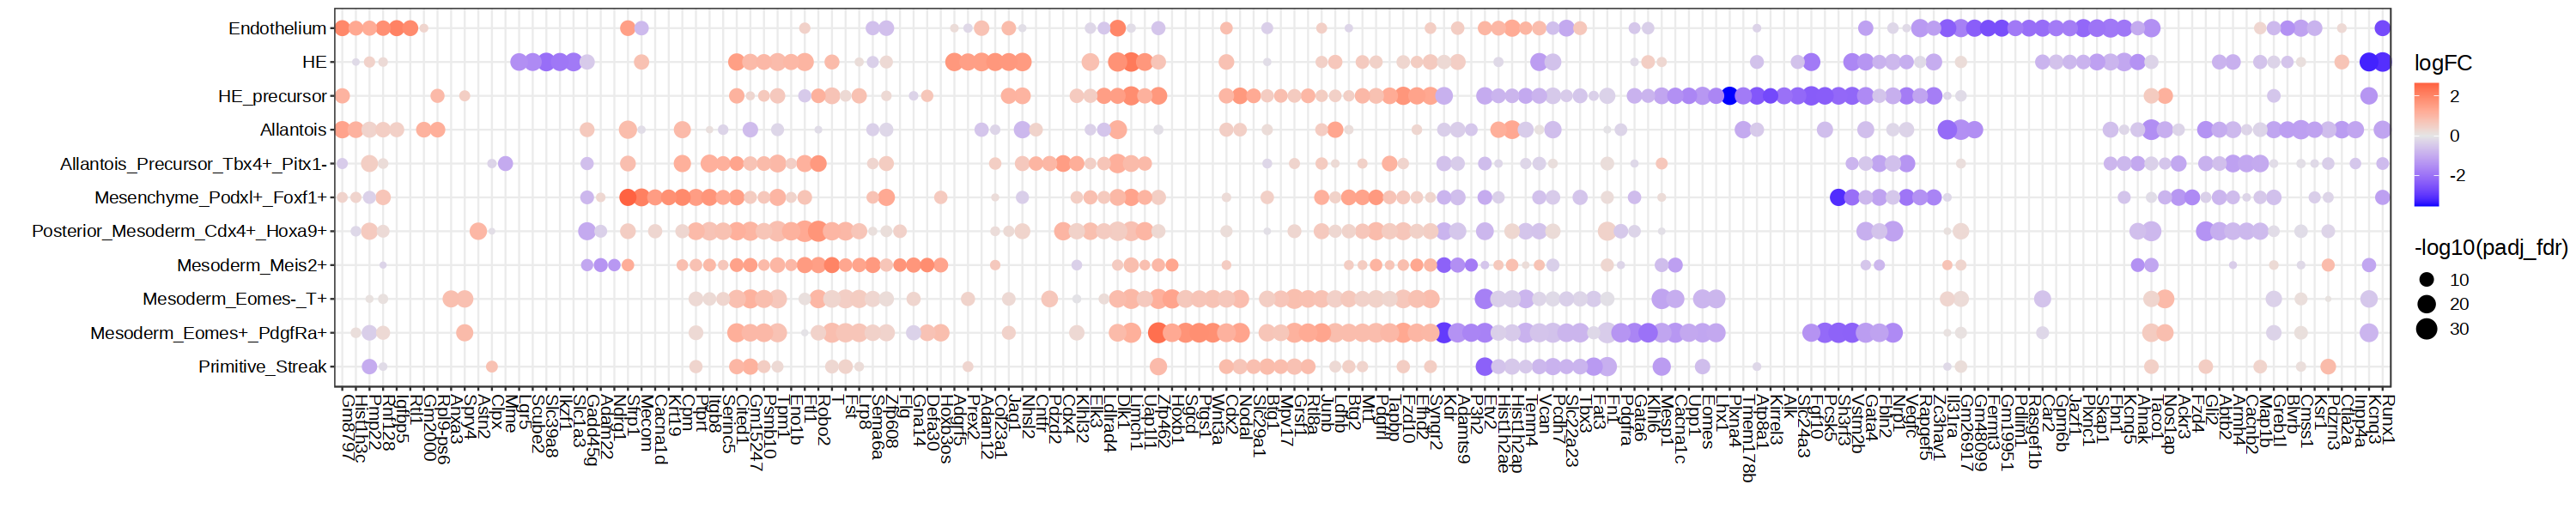

In [233]:
features = unique(DEGs[padj_fdr<0.05 & abs(logFC) > 0.75] %>% .[order(-abs(logFC)), ]) %>% .[,head(.SD, 20), by=celltype] %>% .$gene

# Turn dt in matrix
DEGs.mtx = DEGs[gene %in% features ,c('gene',  'logFC', 'celltype')] %>% dcast(., celltype ~ gene, value.var = 'logFC')
DEGs.mtx[is.na(DEGs.mtx)] = 0
DEGs.mtx = DEGs.mtx %>% as.data.frame() %>% tibble::column_to_rownames('celltype')

# Cluster genes by logFC
order = hclust(dist(t(DEGs.mtx)))

# prepare data.table for plotting
to.plot = DEGs[gene %in% features & padj_fdr < 0.05] %>%
    .[, gene := factor(gene, levels = order$labels[order$order])] %>%
    .[, celltype := factor(celltype, levels = keep)]

options(repr.plot.width=12, repr.plot.height=4)
ggplot(to.plot, aes(gene, celltype, size=-log10(padj_fdr), col=logFC)) + 
    geom_point() + 
    scale_color_gradient2(low='blue', mid = 'gray90', high='red', name='logFC') + 
    xlab('') + ylab('') + 
    theme_bw() + 
    theme(axis.text.x=element_text(angle=-90, hjust=0, vjust=0.5),
         axis.text=element_text(size=12, color='black'),
         text=element_text(size=15))

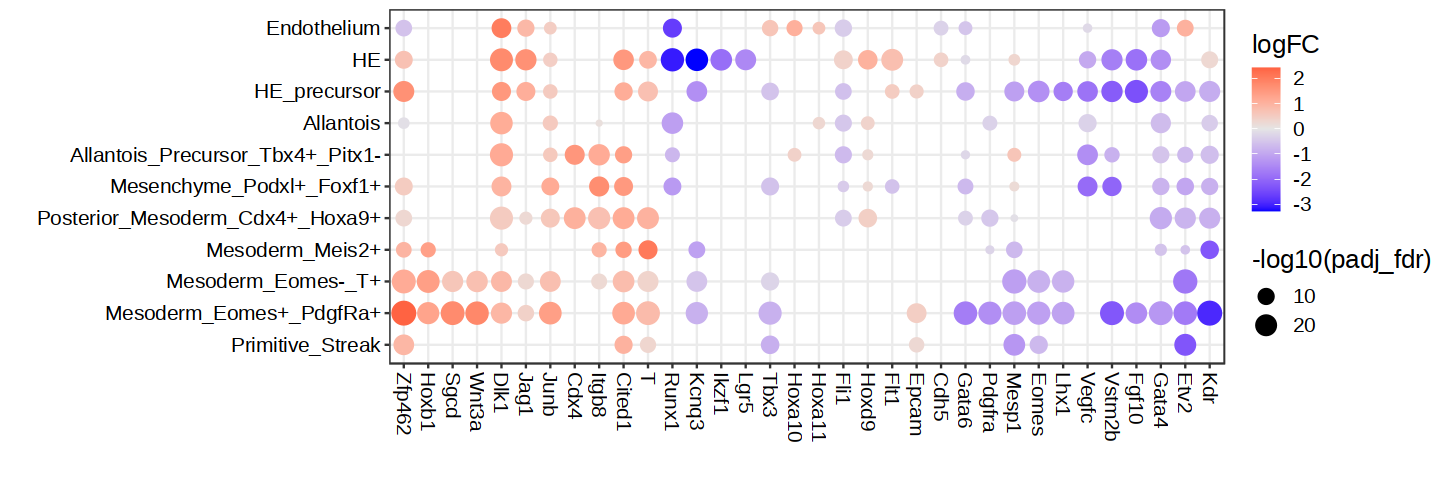

In [248]:
features = c('Kdr', 'Fgf10', 'Runx1', 'Cdh5', 'T', 'Eomes', 'Dlk1', 'Epcam', 
             'Lgr5', 'Itgb8', 'Cited1', 'Flt1', 'Jag1', 'Cdx4', 'Hoxb1', 'Sgcd', 'Junb', 'Tbx3', 'Pdgfra', 'Mesp1', 'Mesp2', 
             'Vstm2b', 'Kcnq3', 'Hoxd9', 'Hoxa10', 'Etv2',
             'Gata6', 'Gata4', 'Lhx1', 'Fli1', 'Wnt3a', 'Zfp462', 'Vegfc', 'Ikzf1', 'Flt3', 'Hoxa11')

# Turn dt in matrix
DEGs.mtx = DEGs[gene %in% features ,c('gene',  'logFC', 'celltype')] %>% dcast(., celltype ~ gene, value.var = 'logFC')
DEGs.mtx[is.na(DEGs.mtx)] = 0
DEGs.mtx = DEGs.mtx %>% as.data.frame() %>% tibble::column_to_rownames('celltype')

# Cluster genes by logFC
order = hclust(dist(t(DEGs.mtx)))

# prepare data.table for plotting
to.plot = DEGs[gene %in% features & padj_fdr < 0.05] %>%
    .[, gene := factor(gene, levels = order$labels[order$order])] %>%
    .[, celltype := factor(celltype, levels = keep)]

options(repr.plot.width=12, repr.plot.height=4)
ggplot(to.plot, aes(gene, celltype, size=-log10(padj_fdr), col=logFC)) + 
    geom_point() + 
    scale_color_gradient2(low='blue', mid = 'gray90', high='red', name='logFC') + 
    xlab('') + ylab('') + 
    theme_bw() + 
    theme(axis.text.x=element_text(angle=-90, hjust=0, vjust=0.5),
         axis.text=element_text(size=12, color='black'),
         text=element_text(size=15))

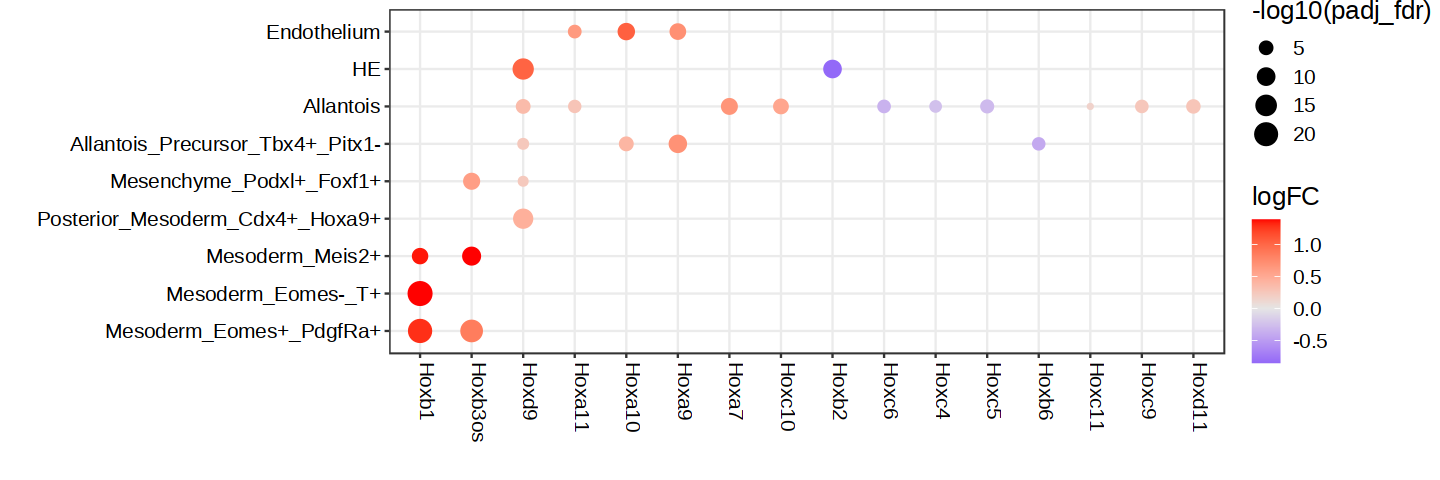

In [240]:
# all Hox genes
features = unique(DEGs$gene)[grep('^Hox', unique(DEGs$gene))]

# Turn dt in matrix
DEGs.mtx = DEGs[gene %in% features ,c('gene',  'logFC', 'celltype')] %>% dcast(., celltype ~ gene, value.var = 'logFC')
DEGs.mtx[is.na(DEGs.mtx)] = 0
DEGs.mtx = DEGs.mtx %>% as.data.frame() %>% tibble::column_to_rownames('celltype')

# Cluster genes by logFC
order = hclust(dist(t(DEGs.mtx)))

# prepare data.table for plotting
to.plot = DEGs[gene %in% features & padj_fdr < 0.05] %>%
    .[, gene := factor(gene, levels = order$labels[order$order])] %>%
    .[, celltype := factor(celltype, levels = keep)]

options(repr.plot.width=12, repr.plot.height=4)
ggplot(to.plot, aes(gene, celltype, size=-log10(padj_fdr), col=logFC)) + 
    geom_point() + 
    scale_color_gradient2(low='blue', mid = 'gray90', high='red', name='logFC') + 
    xlab('') + ylab('') + 
    theme_bw() + 
    theme(axis.text.x=element_text(angle=-90, hjust=0, vjust=0),
         axis.text=element_text(size=12, color='black'),
         text=element_text(size=15))

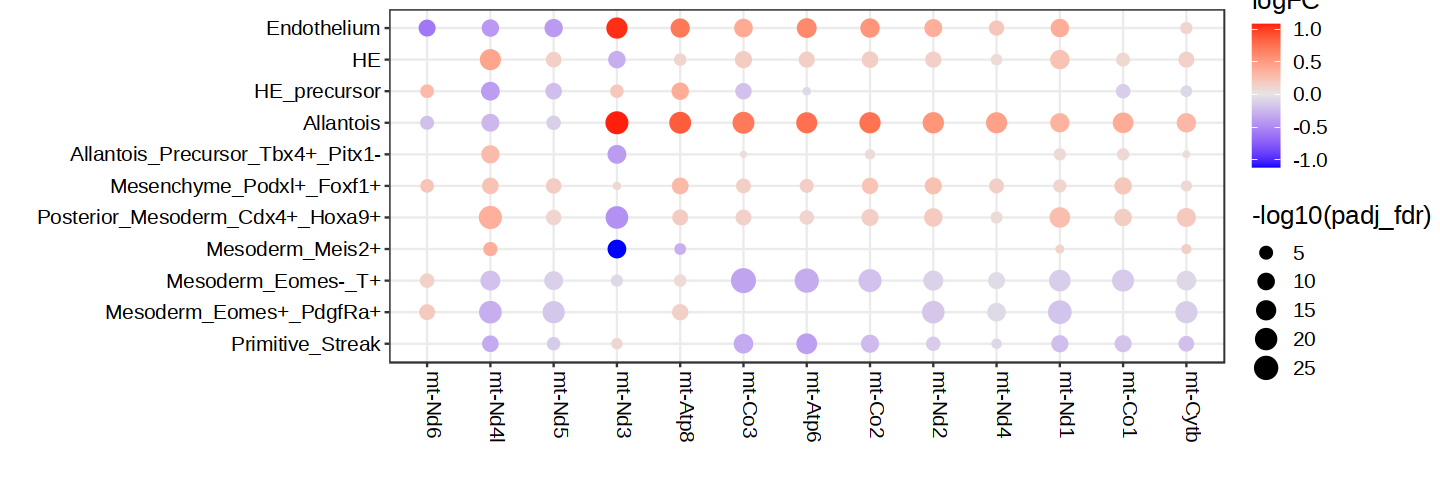

In [247]:
# all Hox genes
features = unique(DEGs$gene)[grep('^mt-', unique(DEGs$gene))]

# Turn dt in matrix
DEGs.mtx = DEGs[gene %in% features ,c('gene',  'logFC', 'celltype')] %>% dcast(., celltype ~ gene, value.var = 'logFC')
DEGs.mtx[is.na(DEGs.mtx)] = 0
DEGs.mtx = DEGs.mtx %>% as.data.frame() %>% tibble::column_to_rownames('celltype')

# Cluster genes by logFC
order = hclust(dist(t(DEGs.mtx)))

# prepare data.table for plotting
to.plot = DEGs[gene %in% features & padj_fdr < 0.05] %>%
    .[, gene := factor(gene, levels = order$labels[order$order])] %>%
    .[, celltype := factor(celltype, levels = keep)]

options(repr.plot.width=12, repr.plot.height=4)
ggplot(to.plot[padj_fdr < 0.05], aes(gene, celltype, size=-log10(padj_fdr), col=logFC)) + 
    geom_point() + 
    scale_color_gradient2(low='blue', mid = 'gray90', high='red', name='logFC') + 
    xlab('') + ylab('') + 
    theme_bw() + 
    theme(axis.text.x=element_text(angle=-90, hjust=0, vjust=0),
         axis.text=element_text(size=12, color='black'),
         text=element_text(size=15))

### EdgeR single-cell

In [90]:
sce = as.SingleCellExperiment(seurat)

In [91]:
sample_metadata = meta[day!='D3']

In [106]:
# Single cell DEG function

doDiffExpr <- function(sce, groups, min_detection_rate_per_group = 0.35) {
    
  # Sanity checks
  if (!is(sce, "SingleCellExperiment")) stop("'sce' has to be an instance of SingleCellExperiment")
  stopifnot(length(groups)==2)

  # Filter genes by detection rate per group
  cdr_A <- rowMeans(counts(sce[,sce$genotype==opts$groups[1]])>0) >= min_detection_rate_per_group
  cdr_B <- rowMeans(counts(sce[,sce$genotype==opts$groups[2]])>0) >= min_detection_rate_per_group
  out <- .edgeR(sce[cdr_B | cdr_A,]) %>% .[,log_padj_fdr:= -log10(padj_fdr)]
  
  return(out)
}


.edgeR <- function(sce) {
  
  # Convert SCE to DGEList
  sce$genotype <- factor(sce$genotype, levels=opts$groups)
  sce_edger <- scran::convertTo(sce, type="edgeR")
 # sce_edger$samples$norm.factors = sce_edger$samples$sizeFactor
    

  design <- model.matrix(~sce$exp+sce$genotype) # might need to modify to only use this if celltype found in both experiments
  # Estimate dispersions
  sce_edger  <- estimateDisp(sce_edger,design)
  
  # Fit GLM
  fit <- glmQLFit(sce_edger,design)
  
  # Likelihood ratio test
  lrt <- glmQLFTest(fit)
  
  # Construct output data.frame
  out <- topTags(lrt, n=nrow(lrt))$table %>% as.data.table(keep.rownames=T) %>%
    setnames(c("gene","logFC","logCPM","LR","p.value","padj_fdr")) %>%
    .[,c("logCPM","LR"):=NULL]
  
  return(out)
}

In [108]:
# Single_cell

sce$group = sample_metadata$genotype
opts$groups = c('wt', 'eomes_ko')
sce$group = factor(sce$group, levels = opts$groups)

de.results = mclapply(keep, function(x){     #unique(meta$celltype.mapped)
    # Only keep cell types with at least 20 cells in both KO and WT
    if(!TRUE %in% as.vector(as.data.frame(table(sample_metadata[celltypes_v1==x, genotype]))$Freq<20) & 
       length(unique(sample_metadata[celltypes_v1==x, genotype]))==2){
        message(x)
        sce_deg = sce[, sample_metadata$celltypes_v1==x]
            out <- doDiffExpr(sce_deg, opts$groups) %>%
              # Add sample statistics
              .[,c("groupA_N","groupB_N"):=list(table(sce_deg$group)[1],table(sce_deg$group)[2])]%>% 
              .[,c("groupA","groupB", "celltype"):=list(opts$groups[1],opts$groups[2],x)]%>%  
              # Calculate statistical significance
              .[, sig := (padj_fdr<=0.05 & abs(logFC)>=1)] %>%
              .[is.na(sig),sig:=FALSE] %>% 
              setorder(-sig, padj_fdr, na.last=T) %>%
              # Add celltype
                .[,celltype:=x]

            # Parse columns
            out[,c("p.value","padj_fdr","logFC","log_padj_fdr"):=list(signif(p.value,digits=3), signif(padj_fdr,digits=3), round(logFC,3),round(log_padj_fdr,3))]
            return(out)
            } 
        }, mc.cores=12) %>% rbindlist()


In [109]:
DEGs = de.results

In [110]:
head(DEGs)

gene,logFC,p.value,padj_fdr,log_padj_fdr,groupA_N,groupB_N,groupA,groupB,celltype,sig
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>,<chr>,<lgl>
Etv2,-1.580,4.78e-49,2.56e-45,44.592,861,447,wt,eomes_ko,Primitive_Streak,TRUE
Mesp1,-1.166,3.60e-36,6.42e-33,32.193,861,447,wt,eomes_ko,Primitive_Streak,TRUE
Gm15247,1.036,3.82e-26,5.11e-23,22.292,861,447,wt,eomes_ko,Primitive_Streak,TRUE
Fn1,-0.743,1.55e-38,4.15e-35,34.382,861,447,wt,eomes_ko,Primitive_Streak,FALSE
Rps2,0.351,5.13e-24,5.49e-21,20.260,861,447,wt,eomes_ko,Primitive_Streak,FALSE
Zfp462,0.815,4.31e-20,3.84e-17,16.415,861,447,wt,eomes_ko,Primitive_Streak,FALSE


In [111]:
fwrite(DEGs, sprintf('%s/DEGs_edgeR_sc.txt.gz', args$outdir))

In [7]:
DEGs = fread(sprintf('%s/DEGs_edgeR_sc.txt.gz', args$outdir))

In [10]:
DEGs[celltype=='HE'][logFC>0.5 & padj_fdr < 0.05] %>%
    .[grep('^Hox', gene)]

gene,logFC,p.value,padj_fdr,log_padj_fdr,groupA_N,groupB_N,groupA,groupB,celltype,sig
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>,<chr>,<lgl>
Hoxd9,0.975,5.33e-26,6.52e-24,23.186,1595,378,wt,eomes_ko,HE,FALSE


In [12]:
DEGs[abs(logFC)>0.5 & padj_fdr < 0.05] %>%
    .[grep('^Hox', gene)]

gene,logFC,p.value,padj_fdr,log_padj_fdr,groupA_N,groupB_N,groupA,groupB,celltype,sig
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>,<chr>,<lgl>
Hoxb1,1.034,3.42e-125,6.22e-123,122.207,6200,1528,wt,eomes_ko,Mesoderm_Eomes+_PdgfRa+,TRUE
Hoxb1,1.036,4.55e-81,3.06e-78,77.514,2240,2941,wt,eomes_ko,Mesoderm_Eomes-_T+,TRUE
Hoxb3os,1.057,7.48e-07,1.33e-04,3.878,89,455,wt,eomes_ko,Mesoderm_Meis2+,TRUE
Hoxb1,0.823,9.46e-05,5.05e-03,2.297,89,455,wt,eomes_ko,Mesoderm_Meis2+,FALSE
Hoxb3os,0.529,9.51e-07,1.73e-05,4.762,1576,293,wt,eomes_ko,Mesenchyme_Podxl+_Foxf1+,FALSE
Hoxa9,0.579,1.02e-06,5.43e-05,4.265,245,814,wt,eomes_ko,Allantois_Precursor_Tbx4+_Pitx1-,FALSE
Hoxa7,0.598,3.96e-09,3.69e-08,7.434,500,2075,wt,eomes_ko,Allantois,FALSE
Hoxc10,0.533,4.16e-08,3.25e-07,6.488,500,2075,wt,eomes_ko,Allantois,FALSE
Hoxd9,0.975,5.33e-26,6.52e-24,23.186,1595,378,wt,eomes_ko,HE,FALSE


In [ ]:
head(DEGs)

In [215]:
DEGs = DEGs[!gene %in% c('Hba-x', 'Hba-a1', 'Hba-a2', 'Hbb-bh1') ]

In [113]:
plots = mclapply(keep, function(x){
    tmp = DEGs[celltype==x][!is.na(logFC)]
    p = volcano_plot(tmp, ntop=10, title=x, logFC_thr=0.5)
    return(p)
})

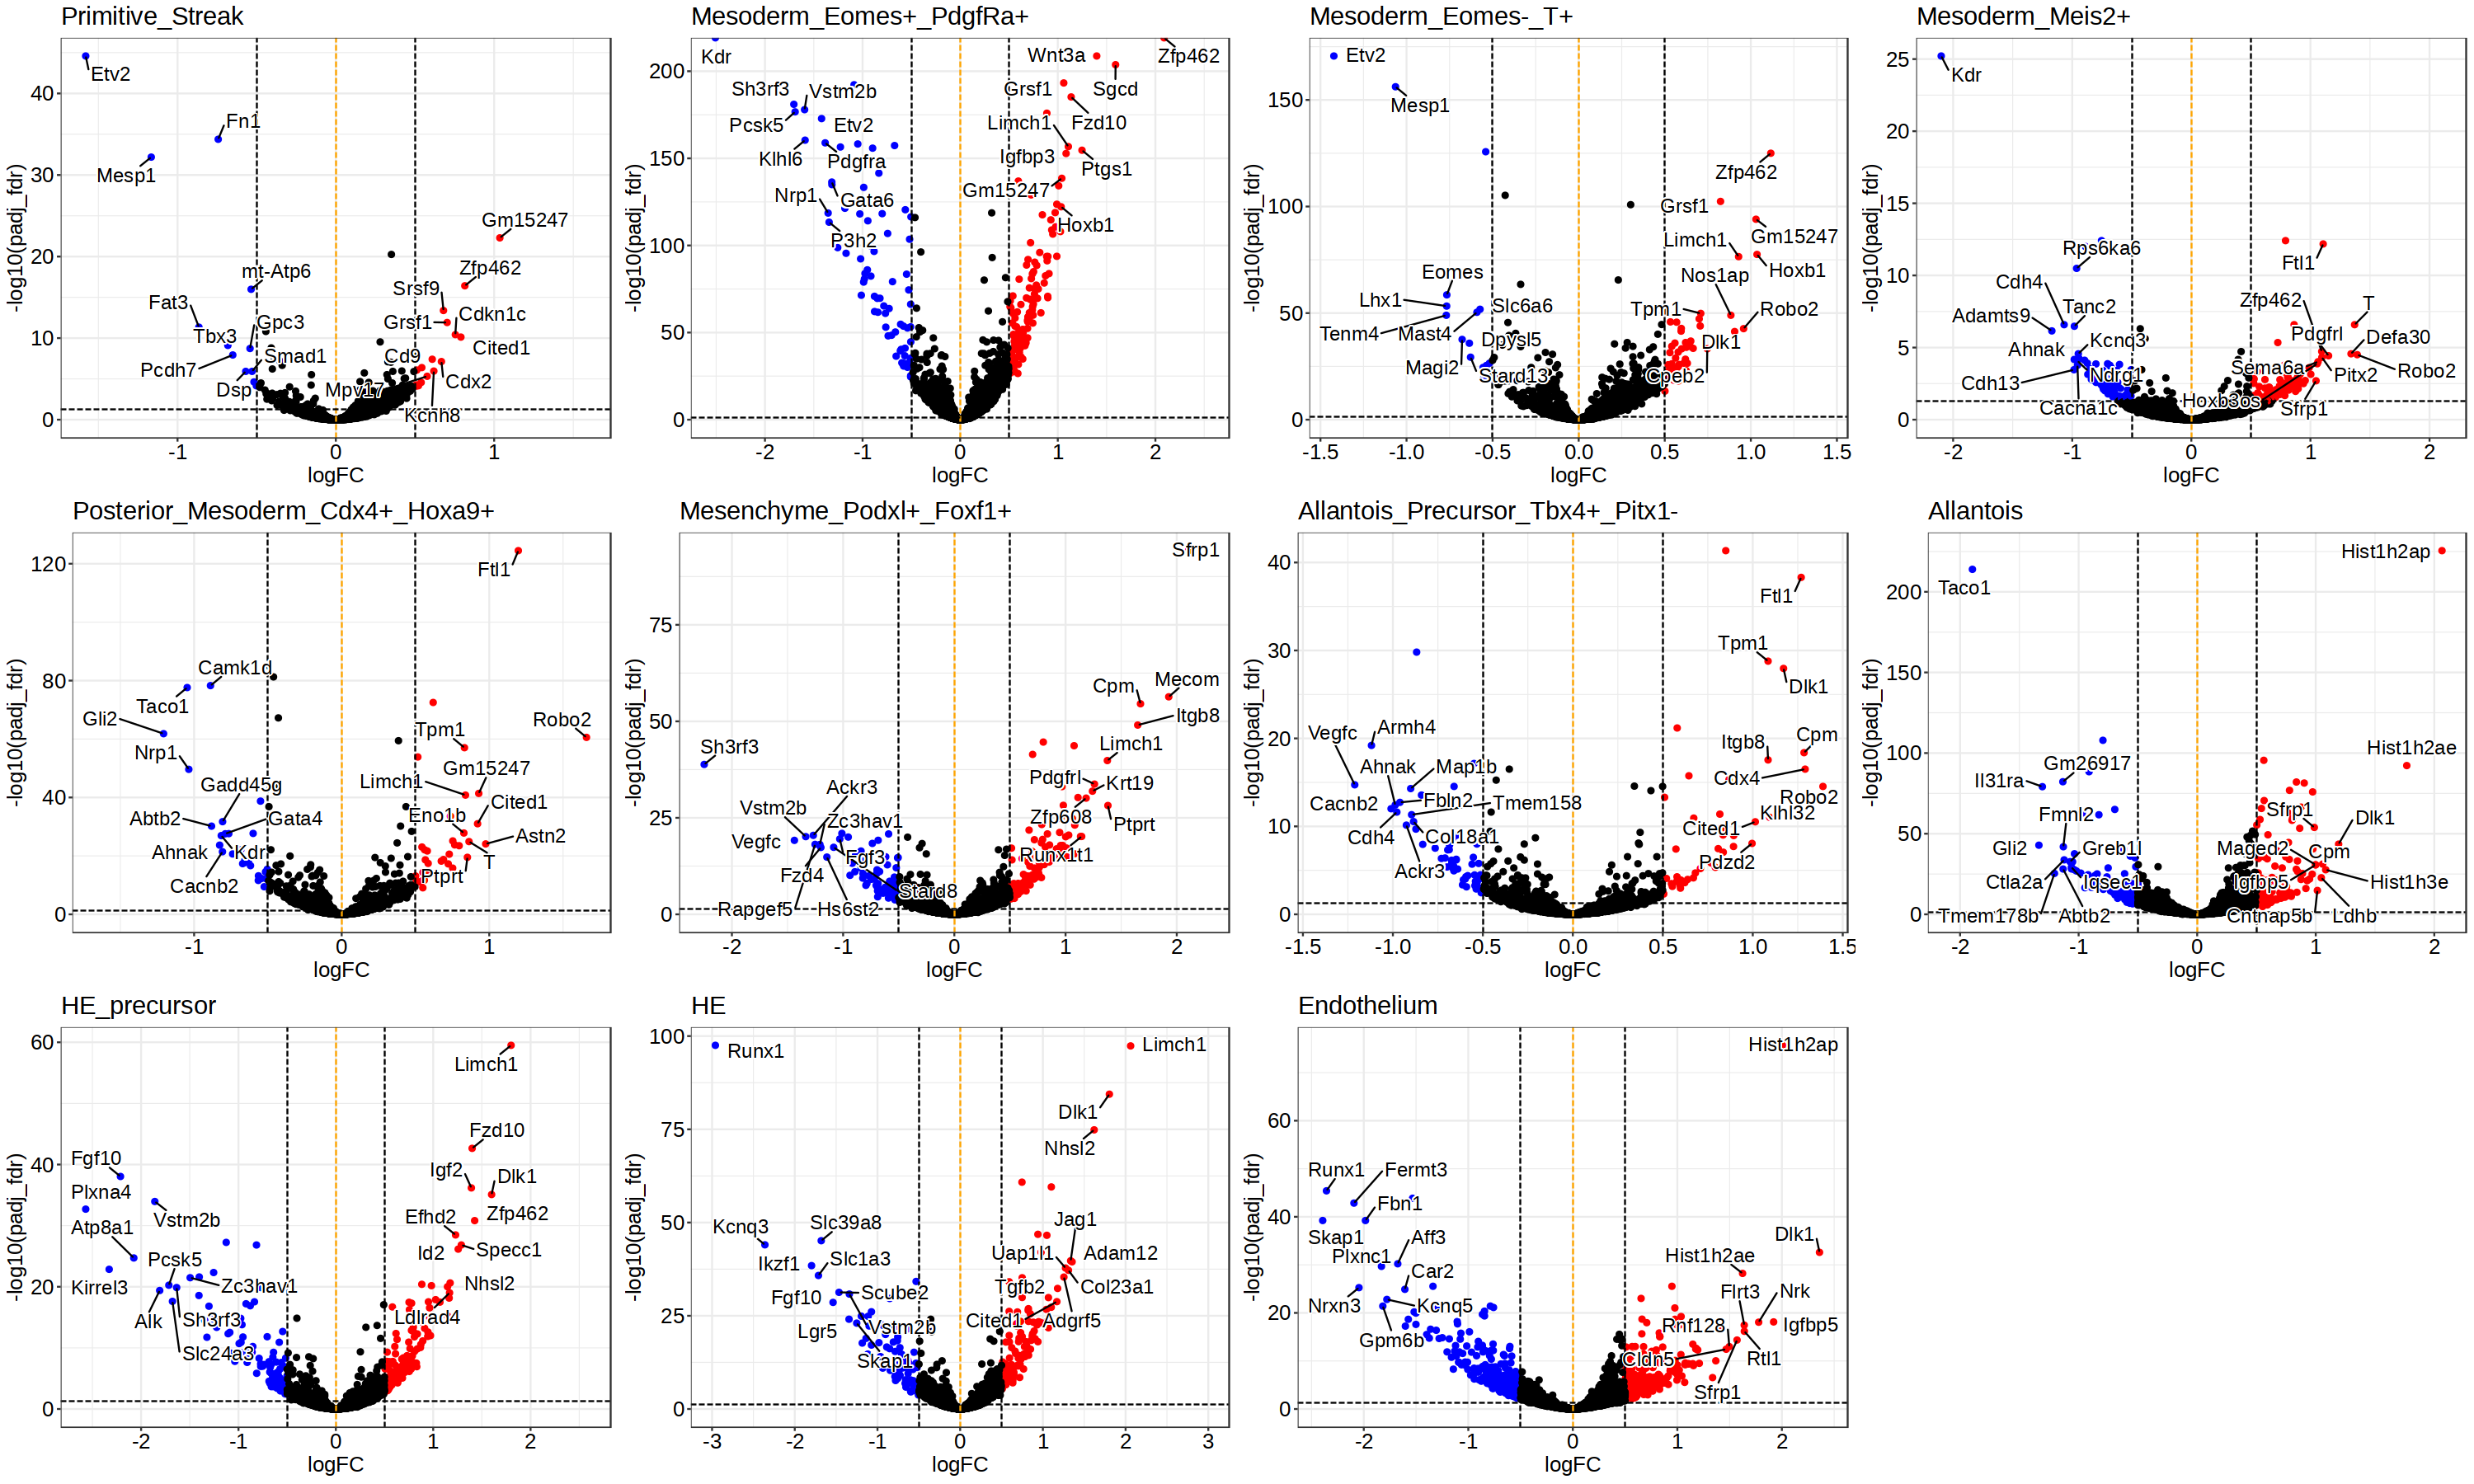

In [114]:
options(repr.plot.width=25, repr.plot.height=15)
ggarrange(plotlist=plots)

In [115]:
levels = lapply(unique(seurat@meta.data$celltypes_v1), function(x){
        t = paste0(x, c('_wt', '_eomes_ko'))
}) %>% unlist

In [116]:
seurat@meta.data$celltypes_genotype = factor(paste0(seurat@meta.data$celltypes_v1, '_', seurat@meta.data$genotype), levels = levels)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


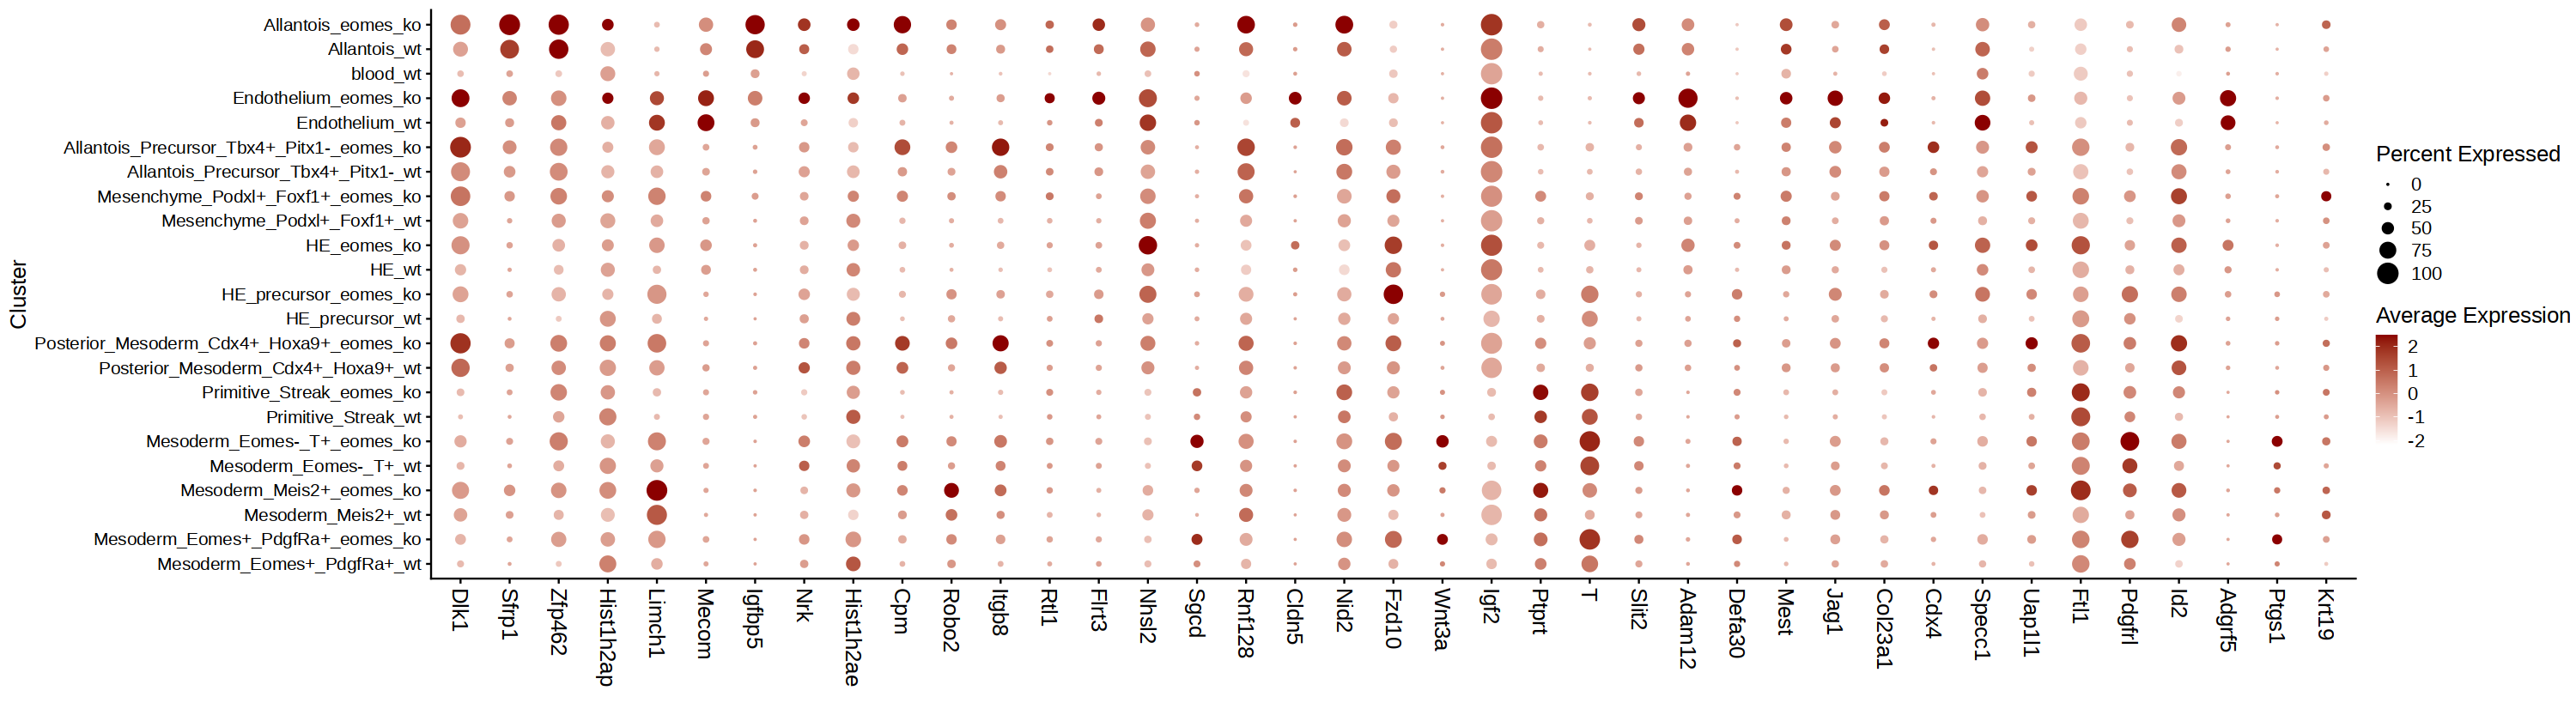

In [117]:
features = unique(DEGs[padj_fdr<0.05] %>% .[order(-logFC), gene] %>% head(50))

options(repr.plot.width=25, repr.plot.height=7)
DotPlot(seurat, features = unique(features), group.by = 'celltypes_genotype') + 
    scale_color_gradient(low='white', high='darkred', name='Average Expression') + 
    RotatedAxis() +
    ylab('Cluster') + xlab('') +
    theme(text=element_text(size=15), 
                         axis.text.x=element_text(angle=-90,hjust=0,vjust=0.5, size=15), 
                         axis.text.y=element_text(hjust=1))

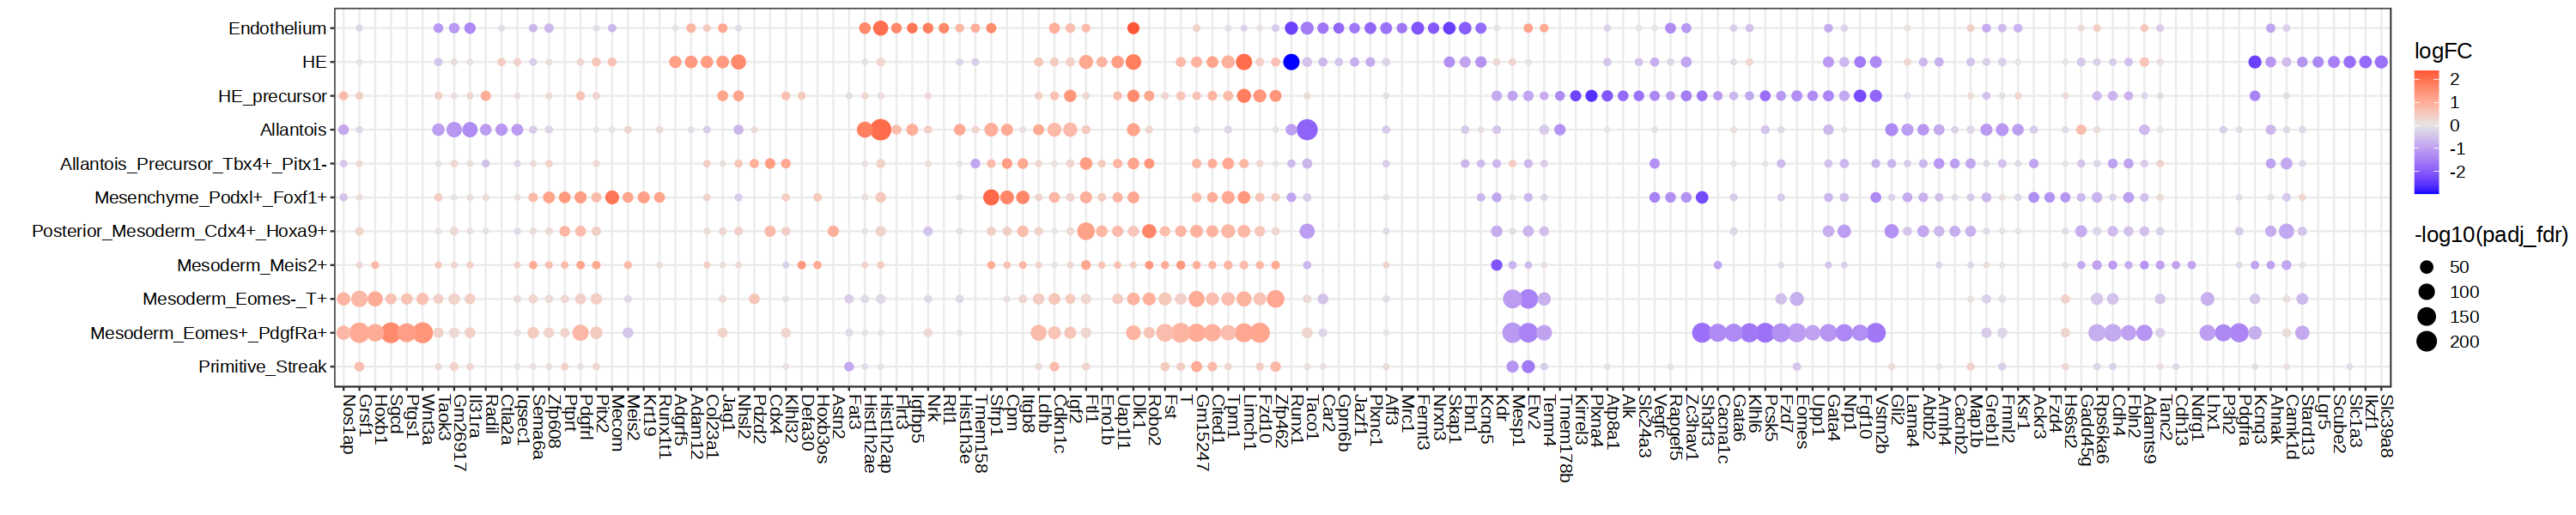

In [224]:
features = unique(DEGs[padj_fdr<0.05 & abs(logFC) > 0.75] %>% .[order(-abs(logFC)), ]) %>% .[,head(.SD, 20), by=celltype] %>% .$gene

# Turn dt in matrix
DEGs.mtx = DEGs[gene %in% features ,c('gene',  'logFC', 'celltype')] %>% dcast(., celltype ~ gene, value.var = 'logFC')
DEGs.mtx[is.na(DEGs.mtx)] = 0
DEGs.mtx = DEGs.mtx %>% as.data.frame() %>% tibble::column_to_rownames('celltype')

# Cluster genes by logFC
order = hclust(dist(t(DEGs.mtx)))

# prepare data.table for plotting
to.plot = DEGs[gene %in% features & padj_fdr < 0.05] %>%
    .[, gene := factor(gene, levels = order$labels[order$order])] %>%
    .[, celltype := factor(celltype, levels = keep)]

options(repr.plot.width=12, repr.plot.height=4)
ggplot(to.plot, aes(gene, celltype, size=-log10(padj_fdr), col=logFC)) + 
    geom_point() + 
    scale_color_gradient2(low='blue', mid = 'gray90', high='red', name='logFC') + 
    xlab('') + ylab('') + 
    theme_bw() + 
    theme(axis.text.x=element_text(angle=-90, hjust=0, vjust=0.5),
         axis.text=element_text(size=12, color='black'),
         text=element_text(size=15))

In [225]:
features

[1] "Runx1"     "Kcnq3"     "Limch1"    "Dlk1"      "Ikzf1"     "Slc1a3"   
  [7] "Slc39a8"   "Nhsl2"     "Fgf10"     "Scube2"    "Adam12"    "Lgr5"     
 [13] "Vstm2b"    "Jag1"      "Col23a1"   "Uap1l1"    "Adgrf5"    "Skap1"    
 [19] "Kcnq5"     "Stard13"   "Plxna4"    "Kirrel3"   "Fgf10"     "Atp8a1"   
 [25] "Vstm2b"    "Alk"       "Limch1"    "Pcsk5"     "Slc24a3"   "Sh3rf3"   
 [31] "Dlk1"      "Zc3hav1"   "Zfp462"    "Kcnq3"     "Gata4"     "Fzd10"    
 [37] "Igf2"      "Vegfc"     "Tmem178b"  "Upp1"      "Kdr"       "Zfp462"   
 [43] "Sh3rf3"    "Pcsk5"     "Vstm2b"    "Sgcd"      "Klhl6"     "Etv2"     
 [49] "Wnt3a"     "Pdgfra"    "Nrp1"      "P3h2"      "Gata6"     "Cacna1c"  
 [55] "Fgf10"     "Ptgs1"     "Fzd7"      "Gata4"     "Adamts9"   "Fzd10"    
 [61] "Skap1"     "Dlk1"      "Runx1"     "Fermt3"    "Nrxn3"     "Hist1h2ap"
 [67] "Fbn1"      "Igfbp5"    "Plxnc1"    "Gpm6b"     "Kcnq5"     "Nrk"      
 [73] "Aff3"      "Rtl1"      "Flrt3"     "Hist1h2ae" "Car2"      "Mrc1"     
 [79] "Jazf1"     "Sfrp1"     "Sh3rf3"    "Sfrp1"     "Mecom"     "Cpm"      
 [85] "Itgb8"     "Vegfc"     "Ptprt"     "Limch1"    "Vstm2b"    "Ackr3"    
 [91] "Pdgfrl"    "Rapgef5"   "Krt19"     "Zc3hav1"   "Fzd4"      "Zfp608"   
 [97] "Hs6st2"    "Runx1t1"   "Meis2"     "Dlk1"      "Kdr"       "Robo2"    
[103] "T"         "Defa30"    "Adamts9"   "Pdgfrl"    "Ftl1"      "Pitx2"    
[109] "Zfp462"    "Cdh4"      "Sema6a"    "Hoxb3os"   "Sfrp1"     "Fst"      
[115] "Gm15247"   "Cdh13"     "Ahnak"     "Tanc2"     "Rps6ka6"   "Ndrg1"    
[121] "Hist1h2ap" "Taco1"     "Hist1h2ae" "Gli2"      "Il31ra"    "Tmem178b" 
[127] "Dlk1"      "Gm26917"   "Abtb2"     "Fmnl2"     "Ctla2a"    "Hist1h3e" 
[133] "Greb1l"    "Iqsec1"    "Radil"     "Cpm"       "Lama4"     "Ldhb"     
[139] "Ksr1"      "Taok3"     "Robo2"     "Gli2"      "Ftl1"      "Taco1"    
[145] "Nrp1"      "Astn2"     "Gm15247"   "Cited1"    "Camk1d"    "Abtb2"    
[151] "T"         "Ptprt"     "Limch1"    "Tpm1"      "Eno1b"     "Ahnak"    
[157] "Kdr"       "Cacnb2"    "Gadd45g"   "Cdx4"      "Etv2"      "Mesp1"    
[163] "Gm15247"   "Fat3"      "Zfp462"    "Cited1"    "Cdkn1c"    "Etv2"     
[169] "Zfp462"    "Mesp1"     "Hoxb1"     "Gm15247"   "Robo2"     "Limch1"   
[175] "Dlk1"      "Nos1ap"    "Grsf1"     "Tenm4"     "Lhx1"      "Eomes"    
[181] "Robo2"     "Cdx4"      "Cpm"       "Ftl1"      "Vegfc"     "Dlk1"     
[187] "Armh4"     "Klhl32"    "Tpm1"      "Itgb8"     "Cited1"    "Cacnb2"   
[193] "Pdzd2"     "Ahnak"     "Cdh4"      "Fbln2"     "Ackr3"     "Map1b"    
[199] "Tmem158"   "Uap1l1"